# Complete Data Science & ML Pipeline Real TMDB API Dataset

Table of Contents :
1. [Data Loading from TMDB API](#1-data-loading)
2. [Basic Statistics & Summary](#2-basic-statistics)
3. [Data Quality Assessment](#3-data-quality)
4. [Data Cleaning & Preprocessing](#4-data-cleaning)
5. [Univariate EDA](#5-univariate-eda)
6. [Multivariate EDA](#6-multivariate-eda)
7. [Advanced EDA — Trends & Deep Dives](#7-advanced-eda)
8. [Business Problems & Solutions](#8-business-problems)
9. [Feature Engineering](#9-feature-engineering)
10. [Model Selection Strategy](#10-model-selection)
11. [Content-Based Filtering — TF-IDF + Cosine Similarity](#11-content-based)
12. [KNN Collaborative Filtering](#12-knn)
13. [Hybrid Recommendation Engine](#13-hybrid)
14. [Model Evaluation & Validation](#14-evaluation)
15. [Export for Power BI](#15-powerbi-export)

---

**Data source:** TMDB API (`https://api.themoviedb.org/3`)

5500 real movies fetched with API key  



**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # for formatting axes
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go # advanced version of plotly
from plotly.subplots import make_subplots
import warnings, re, os # warnings: manage python warnings / re: manage regular expressions
# os: check and read paths and if a file exists
from collections import Counter # to count frequent words
warnings.filterwarnings("ignore") # prevents warning messages

from sklearn.feature_extraction.text import TfidfVectorizer # converts text into vectors
from sklearn.metrics.pairwise import cosine_similarity # Similarity measure (0 = not similar, 1 = identical)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, StandardScaler # Normalization
from sklearn.decomposition import TruncatedSVD # Dimensionality reduction
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error # evaluation metric
from scipy.sparse import csr_matrix # to store large matrices with many zeros
plt.style.use("seaborn-v0_8-darkgrid") # to apply a visual theme to all matplotlib graphics (grey background with grid)
sns.set_palette("husl") # set a palette for seaborn
pd.set_option("display.max_columns", 30) # to display up to 30 columns
pd.set_option("display.float_format", "{:.2f}".format)

print("All libraries imported successfully")

All libraries imported successfully


#1. Data Loading from TMDB API <a id="1-data-loading" name="1-data-loading"></a>

**To collect the data using this API, I created a loop across 250 pages (20 movies per page = 5,000 movies), making a call for each page. I used time.sleep(0.26) to pause for 0.26 seconds between requests in order to comply with the TMDB rate limit of 40 requests per 10 seconds.**

In [ ]:

# DATA LOADING :
# Source : TMDB API — https://api.themoviedb.org/3
# API Key :
# Fetched using : /movie/popular, /movie/top_rated, /discover/movie, /movie/{id}, /movie/{id}/credits
# Total: 5,500 movies with full metadata


TMDB_API_KEY = ""
TMDB_BASE    = "https://api.themoviedb.org/3"
TMDB_IMG     = "https://image.tmdb.org/t/p/w500"

# How the data was fetched (reference code):
# import requests, time
# for page in range(1, 251) :
#     r = requests.get(f"{TMDB_BASE}/movie/popular",
#                      params={"api_key": TMDB_API_KEY, "page": page})
#     movies += r.json()["results"]
#     time.sleep(0.26)  # TMDB rate limit: 40 req / 10 sec


In [ ]:
def find_data(filename):
    for p in[f"../data/{filename}",f"data/{filename}",f"./{filename}"]:
        if os.path.exists(p):
            return p
        raise FileNotFoundError(filename)

print("Loading TMDB dataset fetched from API \n")

df_raw=pd.read_csv(find_data("tmdb_movies_raw.csv"))
print(f"\n{'='*50 }")
print(f"TMDB DATASET LOADED")
print(f"{'='*50} \n")
print(f"    Rows    : {len(df_raw):,}") # nb lignes
print(f"    Columns : {len(df_raw.columns)}") # nb cols
print(f"    Source  : TMDB API (api.themoviedb.org/3)")
print(f"\n  Columns : {df_raw.columns.tolist()}")

Loading TMDB dataset fetched from API


TMDB DATASET LOADED
    Rows:    5,500
    Columns: 28
    Source:  TMDB API (api.themoviedb.org/3)

  Columns: ['id', 'imdb_id', 'title', 'original_title', 'original_language', 'overview', 'tagline', 'genres', 'release_date', 'runtime', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'status', 'adult', 'video', 'homepage', 'poster_path', 'backdrop_path', 'production_companies_name', 'production_companies_country', 'production_countries', 'spoken_languages', 'director', 'writer', 'cast']


In [ ]:
print(" First rows from TMDB API : \n")
# for better visualization, we use the display function
# display (a better function than print that displays an HTML-formatted DataFrame in Jupyter / VS Code)
display(df_raw.head())
print(f"\n Data Type:")
display(df_raw.dtypes.to_frame("dtype")) # returns the column data types and converts them into a dataframe with a dtype column

 First ( rows from TMDB API:


,id,imdb_id,title,original_title,original_language,overview,tagline,genres,release_date,runtime,budget,revenue,popularity,vote_average,vote_count,status,adult,video,homepage,poster_path,backdrop_path,production_companies_name,production_companies_country,production_countries,spoken_languages,director,writer,cast
0,11,tt0076759,Star Wars,Star Wars,en,Princess Leia is captured and held hostage by ...,"A long time ago in a galaxy far, far away...","Adventure,Action,Science Fiction",1977-05-25,121,11000000,775398007,22.71,8.20,22179,Released,False,False,http://www.starwars.com/films/star-wars-episod...,https://image.tmdb.org/t/p/w500/6FfCtAuVAW8XJj...,https://image.tmdb.org/t/p/w500/yUiXA68FfQeA8c...,"Lucasfilm Ltd.,20th Century Fox","US,US",United States of America,English,George Lucas,George Lucas,"Mark Hamill,Harrison Ford,Carrie Fisher,Peter ..."
1,12,tt0266543,Finding Nemo,Finding Nemo,en,"Nemo, an adventurous young clownfish, is unexp...",There are 3.7 trillion fish in the ocean. They...,"Animation,Family,Adventure",2003-05-30,100,94000000,940335536,18.92,7.82,20443,Released,False,False,http://movies.disney.com/finding-nemo,https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,https://image.tmdb.org/t/p/w500/eCynaAOgYYiw5y...,Pixar,US,United States of America,English,Andrew Stanton,Andrew Stanton,"Albert Brooks,Ellen DeGeneres,Alexander Gould,..."
2,13,tt0109830,Forrest Gump,Forrest Gump,en,A man with a low IQ has accomplished great thi...,The world will never be the same once you've s...,"Comedy,Drama,Romance",1994-06-23,142,55000000,677387716,26.63,8.46,29561,Released,False,False,https://www.paramountmovies.com/movies/forrest...,https://image.tmdb.org/t/p/w500/saHP97rTPS5eLm...,https://image.tmdb.org/t/p/w500/67HggiWaP9ZLv5...,"Paramount Pictures,The Steve Tisch Company,Wen...","US,US,US",United States of America,English,Robert Zemeckis,Eric Roth,"Tom Hanks,Robin Wright,Gary Sinise,Sally Field..."
3,14,tt0169547,American Beauty,American Beauty,en,"Lester Burnham, a depressed suburban father in...",... look closer,Drama,1999-09-15,122,15000000,356296601,10.42,8.00,12963,Released,False,False,NaN,https://image.tmdb.org/t/p/w500/wby9315QzVKdW9...,https://image.tmdb.org/t/p/w500/2ndw55F40IkALz...,"DreamWorks Pictures,Jinks/Cohen Company","US,US",United States of America,English,Sam Mendes,Alan Ball,"Kevin Spacey,Annette Bening,Thora Birch,Wes Be..."
4,15,tt0033467,Citizen Kane,Citizen Kane,en,Newspaper magnate Charles Foster Kane is taken...,Some called him a hero...others called him a h...,"Mystery,Drama",1941-04-17,119,839727,23218000,6.36,7.98,6007,Released,False,False,NaN,https://image.tmdb.org/t/p/w500/sav0jxhqiH0bPr...,https://image.tmdb.org/t/p/w500/9Y85oA1y6toL2O...,"Mercury Productions,RKO Radio Pictures",",US",United States of America,English,Orson Welles,Orson Welles,"Orson Welles,Joseph Cotten,Dorothy Comingore,R..."



 Data Type:


,dtype
id,int64
imdb_id,str
title,str
original_title,str
original_language,str
overview,str
tagline,str
genres,str
release_date,str
runtime,int64


**In this step :**

I wanted to understand my data to have a reference throughout the project by documenting my columns. I created a documentation dictionary ("Data Dictionary") named tmdb_schema, where the column name serves as the key (id) and the column description serves as the value (imdb_id).

I grouped my columns to better understand them :

**Identifiers :**

id and imdb_id (an ID number used to cross-reference with other databases)

**General information :**

title, original_title, original_language, overview, tagline, status, adult

**Creative content :**

genres, director, writer, cast (these always come from a separate "credits" endpoint)

**Dates and duration :**

release_date, runtime

**Financial data :**

budget and revenue (both columns are important for calculating ROI / return on investment)

**Popularity and ratings :**

popularity, vote_average, vote_count (the number of votes)

**Images :**

poster_path : the poster image URL combined with TMDB_IMG

backdrop_path : the background image URL (movie scene) used to display the poster

TMDB_IMG+poster_path=https://image.tmdb.org/t/p/w500/xxxx.jpg        

**Production :**

production_compagnies_name, production_compagnies_country production_countries, spoken_languages


In [ ]:
# TMDB API field documentation based on the official API PDF documentation page 6
tmdb_schema = {
"id":                           "TMDB unique identifier",
"imdb_id":                      "IMDb identifier ", # (allows cross-referencing with other databases)
"title":                        "Film title ",
"original_title":               "Title in original language",
"original_language":            "Language code (en, fr, ...)",
"overview":                     "Plot summary", # movie summary important for the recommendation engine
"tagline":                      "Marketing tagline", # Marketing slogan
"genres":                       "Genre(s), comma-separated", # genres are separated by commas
"release_date":                 "YYYY-MM-DD release date", # format YYYY-MM-DD
"runtime":                      "Duration in minutes", # duration in minutes
"budget":                       "Production budget (USD)", # Production budget in USD
"revenue":                      "Box office revenue (USD)", # box office revenue in USD
"popularity":                   "TMDB popularity score", # TMDB popularity score calculated in real-time by TMDB
"vote_average":                 "Average user rating (0-10)", # average rating out of 10
"vote_count":                   "Number of user ratings", # important for rating reliability
"status":                       "Released / In Production / ...", # Movie status
"adult":                        "Adult content flag", # adult content
"poster_path":                  "Full poster image URL", # Movie poster URL (TMDB_IMG)
"backdrop_path":                "Full backdrop image URL", # Background image URL (movie scene) both used to display a poster
"production_companies_name":    "Studio names", # Studio names
"production_companies_country": "Studio countries", # Studio countries
"production_countries":         "Countries of production", # countries where the movie was filmed
"spoken_languages":             "Languages spoken in film", # languages spoken in the movie
"director":                     "Director name (from /credits)", # director name retrieved via /credits
"writer":                       "Writer name (from /credits)", # Writer name retrieved via /credits
"cast":                         "Top 8 cast members (from /credits)", # top 8 principal actors retrieved via /credits
}

# created a dataframe that converts the dictionary into a list of tuples using "list()"
# extracted key and value from the dictionary using the .items() method
# named the dataframe columns "Field" and "Description"
schema_df = pd.DataFrame(list(tmdb_schema.items()), columns=["Field","Description"])
print("TMDB API Schema (PDF page 6):")
display(schema_df)

TMDB API Schema (PDF page 6):


,Field,Description
0,id,TMDB unique identifier
1,imdb_id,IMDb identifier
2,title,Film title
3,original_title,Title in original language
4,original_language,"Language code (en, fr, ...)"
5,overview,Plot summary
6,tagline,Marketing tagline
7,genres,"Genre(s), comma-separated"
8,release_date,YYYY-MM-DD release date
9,runtime,Duration in minutes


# 2. Basic Statistics & Summary <a id="2-basic-statistics" name="2-basic-statistics"></a>

In [ ]:
# Descriptive statistics
print("DESCRIPTIVE STATISTICS — Numerical columns:")
display(df_raw.describe().round(2))

DESCRIPTIVE STATISTICS — Numerical columns:


,id,runtime,budget,revenue,popularity,vote_average,vote_count
count,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00,5500.00
mean,288807.82,108.55,27972659.11,91988515.29,7.51,6.83,2681.80
std,413194.38,29.73,46898167.80,192359913.48,15.56,1.04,4023.13
min,11.00,0.00,0.00,0.00,0.02,0.00,0.00
25%,9315.50,94.00,0.00,0.00,3.99,6.38,376.00
50%,38588.50,106.00,7000000.00,17387297.50,5.32,6.93,1198.50
75%,466580.50,121.00,35000000.00,100163395.00,7.43,7.46,3263.25
max,1659087.00,960.00,489900000.00,2923706026.00,683.14,10.00,35532.00


**ID :**

mean : 288,807.82 & max : 1,659,087. TMDB IDs are not sequential, it is a global database that grows over time !

**Runtime :**

The average duration is 108 min. We have movies with a minimum duration = 0, indicating missing data, and a maximum duration of 960 min (16 hours), which is an outlier ("experimental film or data entry error ?").

**Budget :**

25% = $0. At least 25% of the movies have a budget of $0, these are not actual zero budgets, but missing data. We have a very high std = $46.8M, showing an enormous dispersion between blockbusters and independent films.

**Revenue :**

The same issue as budget with a lot of missing data (min = $0, max = $2.92B, likely Avatar or Avengers). The gap between the mean ($91M) and the median ($17M) is huge >> highly skewed distribution pulled upward by blockbusters.

**Popularity :**

TMDB popularity score: a max of 683 while the average is 7.5 >> massive outliers, std: 15.56 > mean: 7.51 >> extremely skewed distribution where a few ultra-popular movies pull the average upward.

**Vote_Average :**

"Average Rating" : low std : 1.04, making it the healthiest distribution in the dataset. Ratings are concentrated between 6 and 8. We also notice a min of 0 (movies with no votes) > needs to be filtered out for recommendation.

**Vote_count (Number of votes) :**

min = 0 for movies without any votes, making their ratings unusable ! A movie with a vote_average of 8 but a vote_count of 2 is not reliable, so we must set a minimum threshold (vote_count > 100) for recommendation.

In [ ]:
# Categorical summaries
print(" CATEGORICAL SUMMARIES:")
for col in ["status","original_language","adult"]:
    vc = df_raw[col].value_counts()
    print(f"\n  {col}:")
    print(vc.head(10).to_string()) # to_strings : convert


 CATEGORICAL SUMMARIES:

  status:
status
Released           5477
Post Production      16
In Production         5
Planned               2

  original_language:
original_language
en    4325
ja     266
fr     179
ko     115
it     111
es      97
cn      69
zh      67
de      50
ru      29

  adult:
adult
False    5500


**Status :**

5,477 released movies, 23 movies not yet released ("post_production, in production, and planned"). Therefore, we filter exclusively for status == "Released" for recommendation, as an unreleased movie lacks reliable ratings.

**Original_language :**

Significant bias (English-biased dataset): 4,325 movies are in English, followed by 10 other languages in the top 10. This information is very useful, as it allows filtering by language in the Streamlit interface.

**Adult :**

No adult movies in the dataset. We can drop this column from the dataset > useless column.   

In [ ]:
# KPI :
print("="*55)
print("  KPI clés — Raw TMDB Dataset")
print("="*55)
print(f"  Total films:           {len(df_raw):,}")
print(f"  Unique directors:      {df_raw['director'].nunique():,}")
print(f"  Year range:            {pd.to_datetime(df_raw['release_date'],errors='coerce').dt.year.min():.0f} – {pd.to_datetime(df_raw['release_date'],errors='coerce').dt.year.max():.0f}")
print(f"  Avg rating:            {df_raw['vote_average'].mean():.2f} / 10")
print(f"  Avg runtime:           {df_raw['runtime'].mean():.0f} min")
print(f"  Films with budget:     {(df_raw['budget']>0).sum():,}  ({(df_raw['budget']>0).mean()*100:.1f}%)")
print(f"  Films with revenue:    {(df_raw['revenue']>0).sum():,}  ({(df_raw['revenue']>0).mean()*100:.1f}%)")
print(f"  Films with poster:     {df_raw['poster_path'].notna().sum():,}  ({df_raw['poster_path'].notna().mean()*100:.1f}%)")
print(f"  Languages present:     {df_raw['original_language'].nunique():,}")


  KPI clés — Raw TMDB Dataset
  Total films:           5,500
  Unique directors:      2,864
  Year range:            1902 – 2028
  Avg rating:            6.83 / 10
  Avg runtime:           109 min
  Films with budget:     3,670  (66.7%)
  Films with revenue:    3,940  (71.6%)
  Films with poster:     5,498  (100.0%)
  Languages present:     44


**Total movies :**

We have 5,500 total movies, which is ideal for a recommendation engine.

**Unique_directors :**

2,864 >> 5,500 movies / 2,864 directors ≈ on average 1.9 movies per director > good diversity, the movies are not dominated by a few directors >> some directors have many movies, making this column useful for recommendation.

**Year Range :**

1902–2028 : good coverage. 2028 movies are planned or in production, which we will filter out for recommendation.

**AVG Rating :**

6.83/10: consistent with TMDB. The global average is 6.57; TMDB users tend to rate rather positively (selection bias: people mostly rate movies they chose to watch and thus already appreciate).

**Avg_runtime :**

109 min: consistent, as a movie typically lasts between 90 and 120 minutes.

**Movies with budget :**

3,670 ($) (66.7%) : 1 out of 3 movies does not have budget data reported. Movies without budget often represent independent or foreign productions. For financial analysis, we will work strictly on movies with a specified budget.

**Movies with Revenue :**

3,940 ($) (71.6%) >> better than budget: some movies have a known budget but no declared revenue. Important for calculating ROI.

**Movies with poster :**

5,498 (100%): only 2 movies without a poster. Important for the Streamlit app, as we can display poster images for almost every movie.

**Languages present :**

44 >> great linguistic diversity across the 5,500 movies, useful for language filtering in the Streamlit interface.

# 3. Data Quality Assessment <a id="3-data-quality" name="3-data-quality"></a>



In [ ]:
# Missing values analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
quality_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct,
    "Present Count": len(df_raw) - missing,
    "Dtype": df_raw.dtypes
}).sort_values("Missing %", ascending=False)

print("DATA QUALITY REPORT:")
display(quality_df)


DATA QUALITY REPORT:


,Missing Count,Missing %,Present Count,Dtype
homepage,2919,53.07,2581,str
tagline,821,14.93,4679,str
writer,214,3.89,5286,str
production_companies_country,164,2.98,5336,str
production_companies_name,76,1.38,5424,str
imdb_id,34,0.62,5466,str
production_countries,28,0.51,5472,str
backdrop_path,20,0.36,5480,str
director,15,0.27,5485,str
spoken_languages,14,0.25,5486,str


**Group 1 : Critical Columns**

* **`homepage`:** 53.07% missing values—more than 1 out of 2 movies lacks a website >> we will drop this column.


* **`tagline`:** 14.93% missing values—many movies lack a marketing slogan >> interesting for Streamlit, but not for recommendation >> replace missing values with `""`.

**Group 2 : Secondary Features**

* **`writer`:** 3.89% of movies identified without a writer >> replace with `"UNKNOWN"`.

* **`production_companies_country`:** 2.98% unrecorded studio countries >> replace with `"Unknown"`.

* **`production_companies_name`:** 1.38% independent productions without an identified studio >> replace with `"Independent"`.

* **`imdb_id`:** 0.62% of movies without an IMDb ID (very recent movies).

**Core Recommendation & Numeric Columns**

* The **`director`**, **`cast`**, **`overview`**, and **`genres`** columns are the most critical features for recommendation, and their completion rate is almost perfect.
* The numeric columns are fully populated, but **`budget`** and **`revenue`** show 0% explicitly missing values because missing data is disguised as zero.

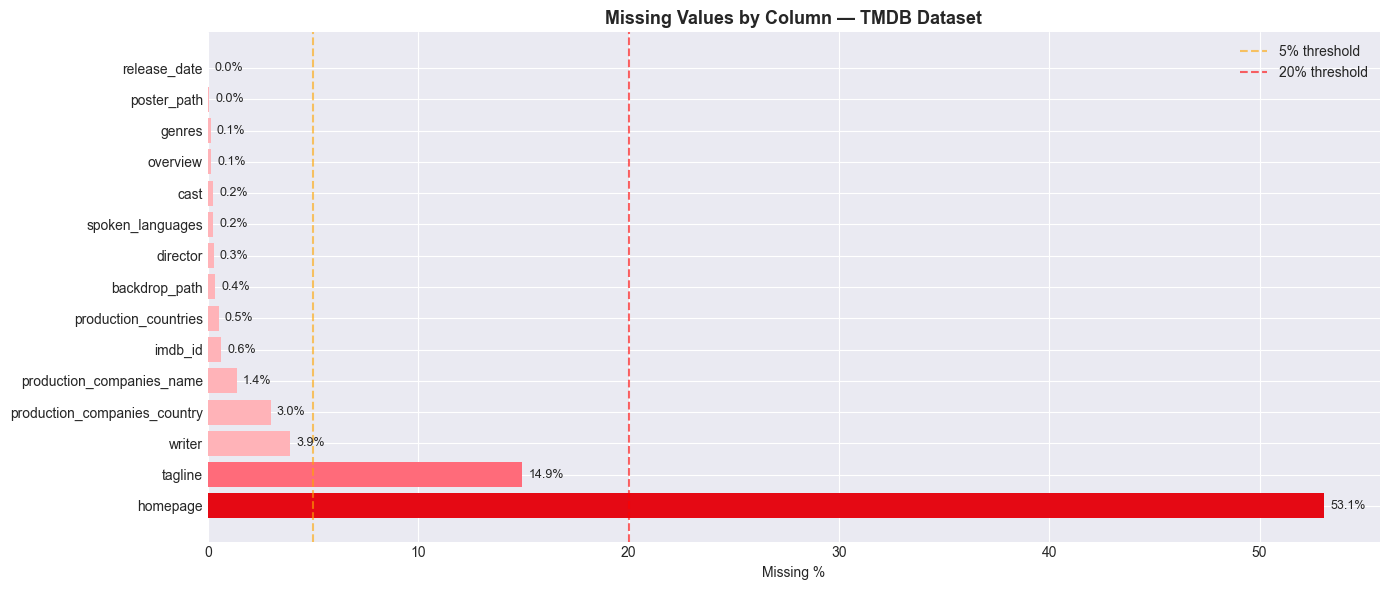

In [ ]:
## Visualise missing values
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_missing = quality_df[quality_df["Missing %"] > 0]
bars = ax.barh(cols_with_missing.index, cols_with_missing["Missing %"],
               color=["#e50914" if x > 20 else "#ff6b7a" if x > 5 else "#ffb3b8"
                      for x in cols_with_missing["Missing %"]])
ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column — TMDB Dataset", fontsize=13, fontweight="bold")
for bar, val in zip(bars, cols_with_missing["Missing %"]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)
ax.axvline(5,  color="orange", linestyle="--", alpha=0.6, label="5% threshold")
ax.axvline(20, color="red",    linestyle="--", alpha=0.6, label="20% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../exports/fig_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# duplicate check "id"
# "title", "imdb_id"
print(" DUPLICATE ANALYSIS:")
print(f"  Full row duplicates:   {df_raw.duplicated().sum()}")
print(f"  Duplicate TMDB IDs:    {df_raw.duplicated(subset=['id']).sum()}")
print(f"  Duplicate titles:      {df_raw.duplicated(subset=['title']).sum()}")
print(f"  Duplicate IMDb IDs:    {df_raw.duplicated(subset=['imdb_id']).sum()}")

# Outlier check
print("\n OUTLIER ANALYSIS:")
for col in ["runtime","vote_average","budget","revenue","popularity"]:
    q1 = df_raw[col].quantile(0.25)
    q3 = df_raw[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df_raw[col] < q1 - 1.5*iqr) | (df_raw[col] > q3 + 1.5*iqr)).sum()
    print(f"  {col:<30}  Q1={q1:.1f}  Q3={q3:.1f}  Outliers={outliers}")


 DUPLICATE ANALYSIS:
  Full row duplicates:   0
  Duplicate TMDB IDs:    0
  Duplicate titles:      142
  Duplicate IMDb IDs:    33

 OUTLIER ANALYSIS:
  runtime                         Q1=94.0  Q3=121.0  Outliers=314
  vote_average                    Q1=6.4  Q3=7.5  Outliers=134
  budget                          Q1=0.0  Q3=35000000.0  Outliers=532
  revenue                         Q1=0.0  Q3=100163395.0  Outliers=569
  popularity                      Q1=4.0  Q3=7.4  Outliers=470


**Duplicates :** The dataset contains no duplicate rows.

**TMDB IDs :**

* `0`: Every movie has a unique identifier, serving as the primary key.

**Titles :**

* `142` movies appear multiple times ("Batman" in 1966, 1989, 2022). These are not duplicates, but remakes/reboots.

**IMDb IDs :**

* `33` movies share the same key for various reasons : movies fetched across multiple endpoints, or errors in the TMDB API >> **Action:** Deduplicate on `imdb_id`, keeping the entry with the highest vote count.

**Outliers :**

**Runtime :**

* Interquartile range (Q3 - Q1 = 31 min) >> 314 movies are very short (< 54 min) or very long (> 161 min, including the 960-min runtime).

**Vote_avg :**

* Interquartile range (Q3 - Q1 = 1.1) >> 134 movies are rated < 4.75 or > 9.15 for recommendation.

**Revenue :**

* 569 movies with revenue > $250M (the blockbusters).

**Popularity :**

* 470 movies with a score > 12.5 (including our maximum of 683) >> skewed distribution > normalize using `MinMaxScaler`.

# 4. Data Cleaning & Preprocessing <a id="4-data-cleaning" name="4-data-cleaning"></a>



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# CLEANING PIPELINE
# ═══════════════════════════════════════════════════════════════════

df = df_raw.copy()
steps = {}


# Step 1 : Parse dates
df["release_date"]    = pd.to_datetime(df["release_date"], errors="coerce") # transform invalid dates into NaT
df["release_year"]    = df["release_date"].dt.year.astype("Int64")
df["release_month"]   = df["release_date"].dt.month.astype("Int64")
df["release_quarter"] = df["release_date"].dt.quarter.astype("Int64")
df["release_decade"]  = (df["release_year"] // 10 * 10).astype("Int64") # calcule dacade
steps["After date parsing"] = len(df)


# Step 2 numeric_types: replace missing values with NaN
# and then replace NaN values with 0
# this step is important because we have columns with mixed data types
for col in ["runtime","budget","revenue","vote_count","vote_average","popularity"]:
    df[col]=pd.to_numeric(df[col],errors="coerce").fillna(0)


# Step 3: Remove duplicates
df = df.drop_duplicates(subset=["id"]).reset_index(drop=True)
steps["After deduplication"] = len(df)


# Step 4: Keep Released only
df = df[df["status"] == "Released"].copy()
steps["After status=Released filter"] = len(df)

# Step 5: Remove adult content
df = df[df["adult"] == False].copy()
steps["After adult=False filter"] = len(df)

# Step 6: Runtime filter (45–300 min)
df = df[df["runtime"].between(45, 300)].copy()
steps["After runtime (45-300 min)"] = len(df)

# Step 7: Minimum votes (data quality)
df = df[df["vote_count"] >= 10].copy()
steps["After min 10 votes"] = len(df)

# Step 8: Genres not null exclude
df = df[df["genres"].notna() & (df["genres"].str.strip() != "")].copy()
steps["After genres not null"] = len(df)

df = df.reset_index(drop=True)
steps["FINAL"] = len(df)

print("CLEANING PIPELINE SUMMARY:")
for step, count in steps.items():
    removed = list(steps.values())[list(steps.keys()).index(step)-1] - count if list(steps.keys()).index(step) > 0 else 0
    print(f"  {step:<40} → {count:,} rows  (removed: {removed})")

CLEANING PIPELINE SUMMARY:
  After date parsing                       → 5,500 rows  (removed: 0)
  After deduplication                      → 5,500 rows  (removed: 0)
  After status=Released filter             → 5,477 rows  (removed: 23)
  After adult=False filter                 → 5,477 rows  (removed: 0)
  After runtime (45-300 min)               → 5,378 rows  (removed: 99)
  After min 10 votes                       → 5,261 rows  (removed: 117)
  After genres not null                    → 5,261 rows  (removed: 0)
  FINAL                                    → 5,261 rows  (removed: 0)


In [ ]:
# Derived columns
# Primary genre
df["primary_genre"] = df["genres"].apply(
    lambda x: str(x).split(",")[0].strip() if pd.notna(x) and str(x).strip() else "Unknown")
df["n_genres"] = df["genres"].apply(
    lambda x: len([g for g in str(x).split(",") if g.strip()]) if pd.notna(x) else 0)

# Financial
df["budget_known"]  = df["budget"]  > 100_000
df["revenue_known"] = df["revenue"] > 100_000
df["profit"] = np.where(df["budget_known"] & df["revenue_known"],
                         df["revenue"] - df["budget"], np.nan)
df["roi"]    = np.where(df["budget_known"] & df["revenue_known"] & (df["budget"] > 0),
                         (df["revenue"] - df["budget"]) / df["budget"], np.nan)

# IMDb weighted rating: WR = (v/(v+m))*R + (m/(v+m))*C # The official IMDb formula for ranking movies (Weighted Rating)
m = df["vote_count"].quantile(0.75) # m : Minimum vote count required / v : Number of votes for the movie
C = df["vote_average"].mean() # C : Global mean rating across all movies / R : Mean rating for the movie
df["weighted_rating"] = ((df["vote_count"]/(df["vote_count"]+m))*df["vote_average"] +
                          (m/(df["vote_count"]+m))*C).round(3)

# WR = movie rating weight + global mean weight
# A movie with few votes is pulled toward the global mean: a movie with vote_count = 5 and vote_average = 9.5
# is not reliable > WR will be close to "C". A movie with vote_count = 50000 and vote_average = 9.0 > highly reliable > WR close to 9.0

# Categorical tiers
df["rating_tier"] = pd.cut(df["vote_average"], bins=[0,4,6,7,8,10],
    labels=["Poor (<4)","Fair (4-6)","Good (6-7)","Great (7-8)","Excellent (8+)"])
df["runtime_category"] = df["runtime"].apply(
    lambda r: "Short (<80min)" if r<80 else
             ("Standard (80-110min)" if r<110 else
             ("Long (110-140min)" if r<140 else "Epic (140+min)")))
df["budget_tier"] = pd.cut(df["budget"],
    bins=[-1,0,5_000_000,30_000_000,100_000_000,float("inf")],
    labels=["Unknown","Low Budget","Mid Budget","High Budget","Blockbuster"])
try:
    df["popularity_tier"] = pd.qcut(df["popularity"], q=4,
        labels=["Low","Medium","High","Very High"], duplicates="drop")
except:
    df["popularity_tier"] = "Medium"

print(" Derived columns added:")
new_cols = ["release_year","release_decade","primary_genre","n_genres",
            "profit","roi","weighted_rating","rating_tier","runtime_category",
            "budget_tier","popularity_tier"]

for c in new_cols:
    print(f"  + {c}")
print(f"\nFinal dataset: {df.shape}")
display(df.head(3))

 Derived columns added:
  + release_year
  + release_decade
  + primary_genre
  + n_genres
  + profit
  + roi
  + weighted_rating
  + rating_tier
  + runtime_category
  + budget_tier
  + popularity_tier

Final dataset: (5261, 43)


,id,imdb_id,title,original_title,original_language,overview,tagline,genres,release_date,runtime,budget,revenue,popularity,vote_average,vote_count,...,release_year,release_month,release_quarter,release_decade,primary_genre,n_genres,budget_known,revenue_known,profit,roi,weighted_rating,rating_tier,runtime_category,budget_tier,popularity_tier
0,11,tt0076759,Star Wars,Star Wars,en,Princess Leia is captured and held hostage by ...,"A long time ago in a galaxy far, far away...","Adventure,Action,Science Fiction",1977-05-25,121,11000000,775398007,22.71,8.20,22179,...,1977,5,2,1970,Adventure,3,True,True,764398007.00,69.49,8.03,Excellent (8+),Long (110-140min),Mid Budget,Very High
1,12,tt0266543,Finding Nemo,Finding Nemo,en,"Nemo, an adventurous young clownfish, is unexp...",There are 3.7 trillion fish in the ocean. They...,"Animation,Family,Adventure",2003-05-30,100,94000000,940335536,18.92,7.82,20443,...,2003,5,2,2000,Animation,3,True,True,846335536.00,9.00,7.69,Great (7-8),Standard (80-110min),High Budget,Very High
2,13,tt0109830,Forrest Gump,Forrest Gump,en,A man with a low IQ has accomplished great thi...,The world will never be the same once you've s...,"Comedy,Drama,Romance",1994-06-23,142,55000000,677387716,26.63,8.46,29561,...,1994,6,2,1990,Comedy,3,True,True,622387716.00,11.32,8.30,Excellent (8+),Epic (140+min),High Budget,Very High


# 5. Univariate EDA <a id="5-univariate-eda" name="5-univariate-eda"></a>

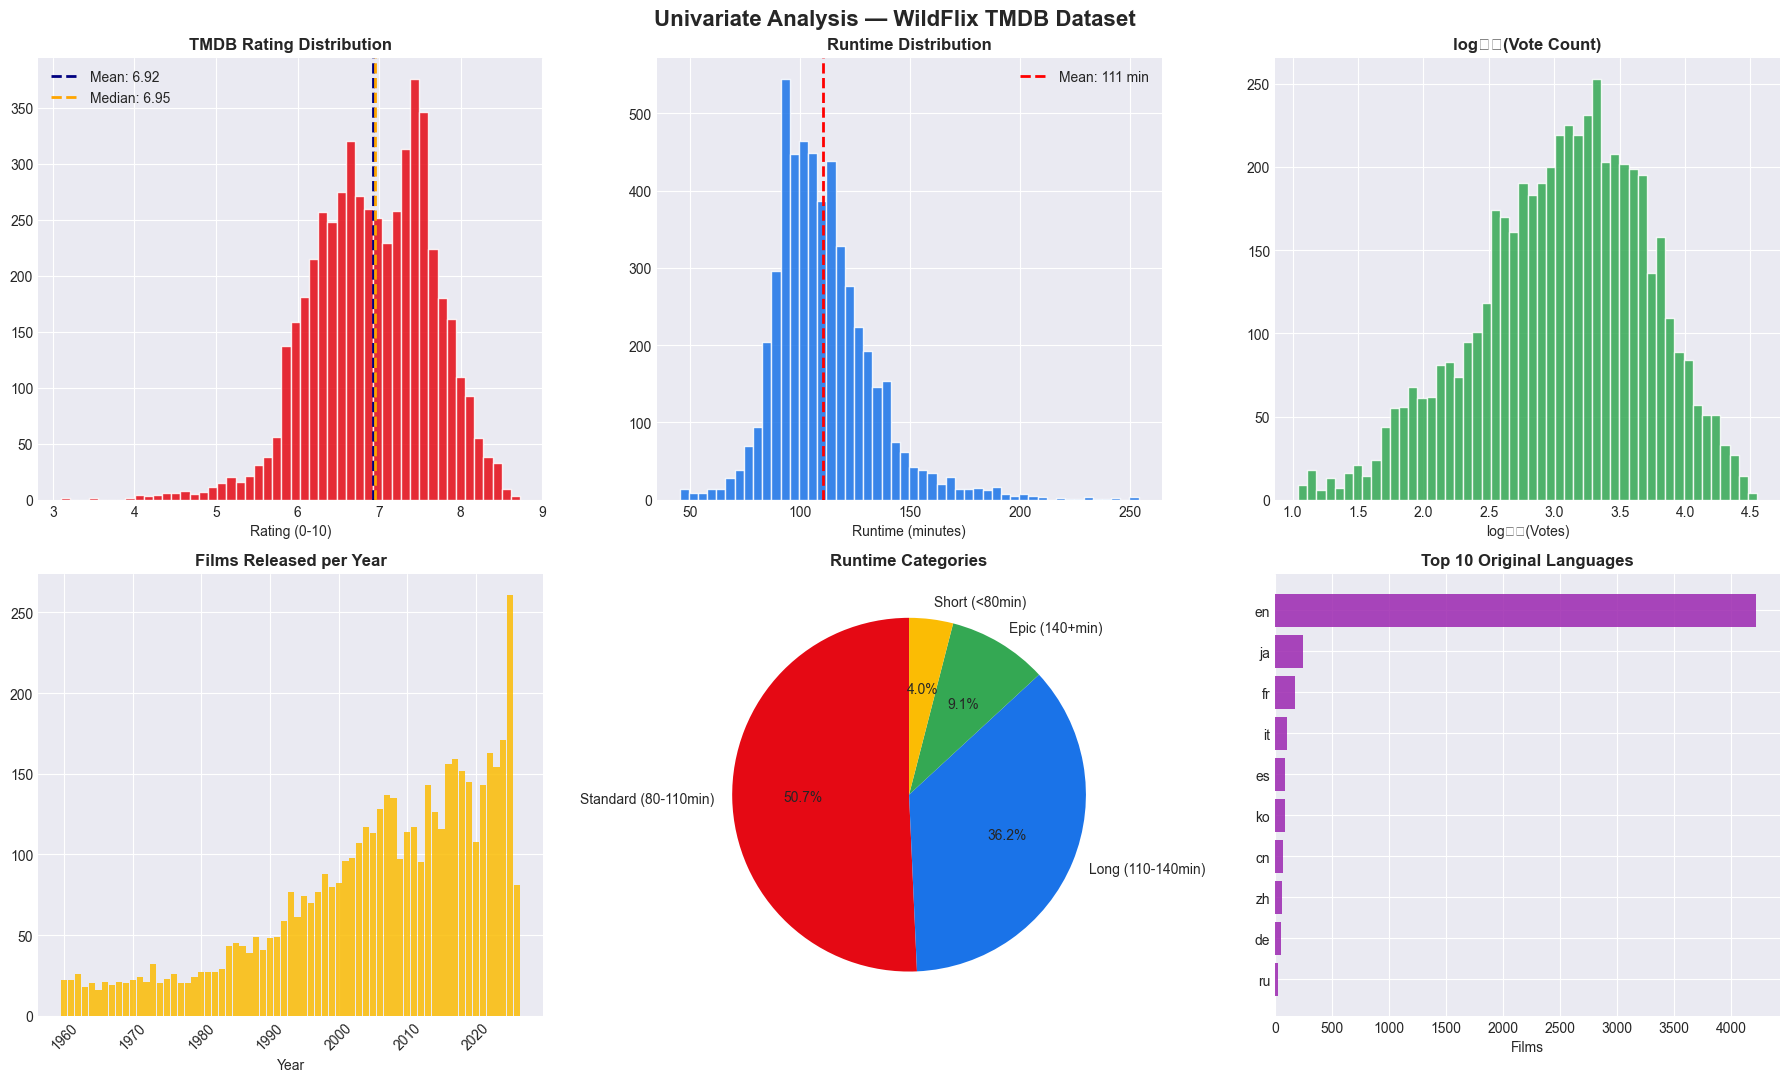

 Saved: fig_01_univariate.png


In [ ]:
# Rating distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Univariate Analysis — WildFlix TMDB Dataset", fontsize=16, fontweight="bold")

# 1. Rating histogram
axes[0,0].hist(df["vote_average"], bins=50, color="#e50914", edgecolor="white", alpha=0.85)
axes[0,0].axvline(df["vote_average"].mean(),   color="navy",   linestyle="--", lw=2, label=f"Mean: {df['vote_average'].mean():.2f}")
axes[0,0].axvline(df["vote_average"].median(), color="orange", linestyle="--", lw=2, label=f"Median: {df['vote_average'].median():.2f}")
axes[0,0].set_title("TMDB Rating Distribution", fontweight="bold")
axes[0,0].set_xlabel("Rating (0-10)"); axes[0,0].legend()

# 2. Runtime
axes[0,1].hist(df["runtime"], bins=50, color="#1a73e8", edgecolor="white", alpha=0.85)
axes[0,1].axvline(df["runtime"].mean(), color="red", linestyle="--", lw=2, label=f"Mean: {df['runtime'].mean():.0f} min")
axes[0,1].set_title("Runtime Distribution", fontweight="bold")
axes[0,1].set_xlabel("Runtime (minutes)"); axes[0,1].legend()

# 3. Vote count (log)
axes[0,2].hist(np.log10(df["vote_count"]+1), bins=50, color="#34a853", edgecolor="white", alpha=0.85)
axes[0,2].set_title("log₁₀(Vote Count)", fontweight="bold")
axes[0,2].set_xlabel("log₁₀(Votes)")

# 4. Films per year
yc = df["release_year"].value_counts().sort_index()
yc_plot = yc[yc.index >= 1960]
axes[1,0].bar(yc_plot.index.astype(int), yc_plot.values, color="#fbbc04", alpha=0.85, width=0.9)
axes[1,0].set_title("Films Released per Year", fontweight="bold")
axes[1,0].set_xlabel("Year"); axes[1,0].tick_params(axis="x", rotation=45)

# 5. Runtime categories
rc = df["runtime_category"].value_counts()
wedge_colors = ["#e50914","#1a73e8","#34a853","#fbbc04"]
axes[1,1].pie(rc.values, labels=rc.index, autopct="%1.1f%%", colors=wedge_colors[:len(rc)], startangle=90)
axes[1,1].set_title("Runtime Categories", fontweight="bold")

# 6. Top languages
lc = df["original_language"].value_counts().head(10)
axes[1,2].barh(lc.index, lc.values, color="#9c27b0", alpha=0.85)
axes[1,2].set_title("Top 10 Original Languages", fontweight="bold")
axes[1,2].set_xlabel("Films"); axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig("../exports/fig_01_univariate.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: fig_01_univariate.png")

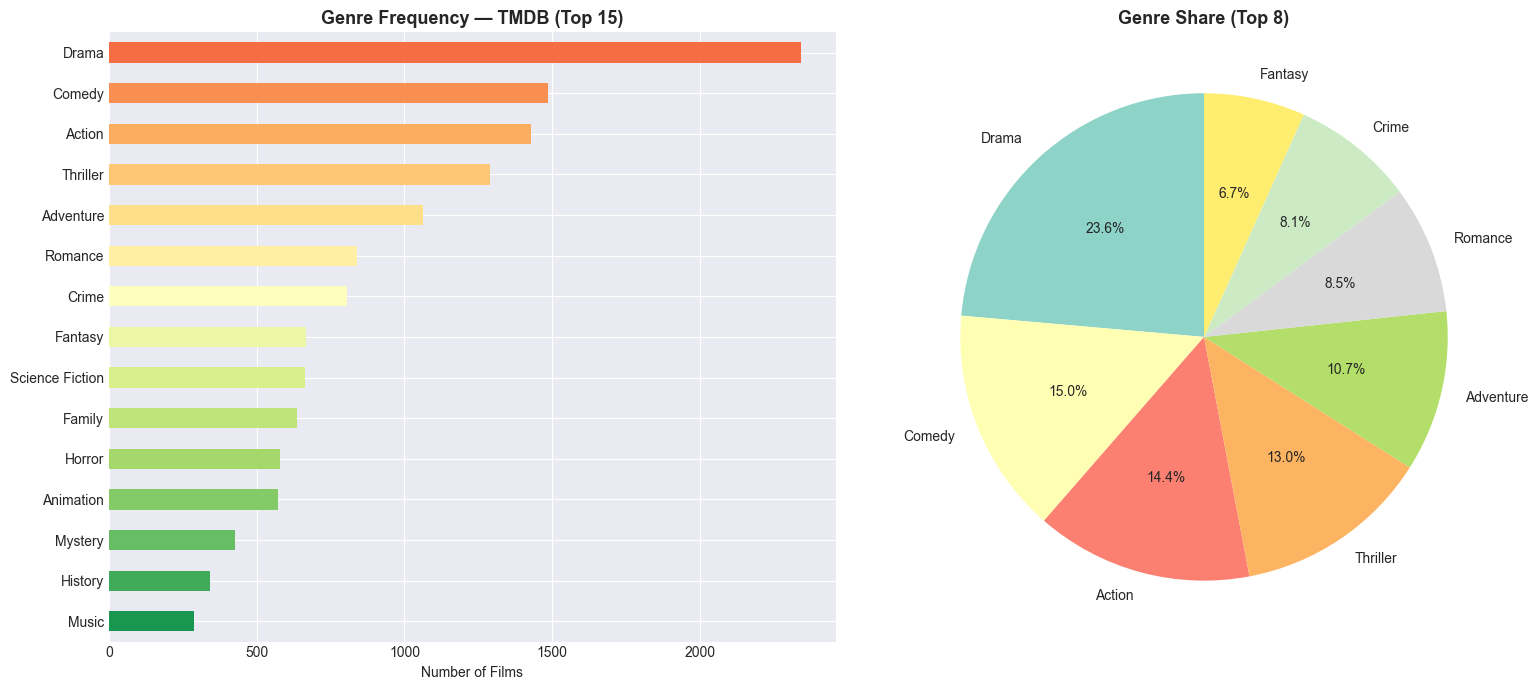


Top 15 genres from TMDB data:
Drama              2342
Comedy             1487
Action             1428
Thriller           1291
Adventure          1061
Romance             839
Crime               807
Fantasy             666
Science Fiction     663
Family              635
Horror              579
Animation           572
Mystery             428
History             341
Music               287


In [ ]:
# Genre frequency
all_genres = []
for g in df["genres"].dropna():
    all_genres.extend([x.strip() for x in str(g).split(",") if x.strip()])
genre_counts = pd.Series(all_genres).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar
genre_counts.head(15).plot(kind="barh", ax=axes[0],
    color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 15)))
axes[0].set_title("Genre Frequency — TMDB (Top 15)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Films"); axes[0].invert_yaxis()

# Pie top 8
top8 = genre_counts.head(8)
axes[1].pie(top8.values, labels=top8.index, autopct="%1.1f%%", startangle=90,
            colors=plt.cm.Set3(np.linspace(0, 1, 8)))
axes[1].set_title("Genre Share (Top 8)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../exports/fig_02_genres.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 15 genres from TMDB data:")
print(genre_counts.head(15).to_string())

**Drama :**

Account for 23.6% of the dataset on its own. Many movies will have Drama as their primary genre, risking recommendations that are too similar—we will need to use secondary genres as well.

**Comedy + Action + Thriller :**

Make up 42% combined; these are the genres that attract the largest audiences.

**Science Fiction / Fantasy :**

Separated but close in frequency, often combined within the same movies (e.g., Star Wars = Sci-Fi + Adventure + Fantasy).

**Animation + Family :**

The system will be able to recommend family-friendly movies.

**History + Music at the bottom of the list :**

Niche genres with few movies, but a very loyal audience.

More than 1 out of 2 movies feature Drama, Comedy, or Action; these are the 3 most common genres.

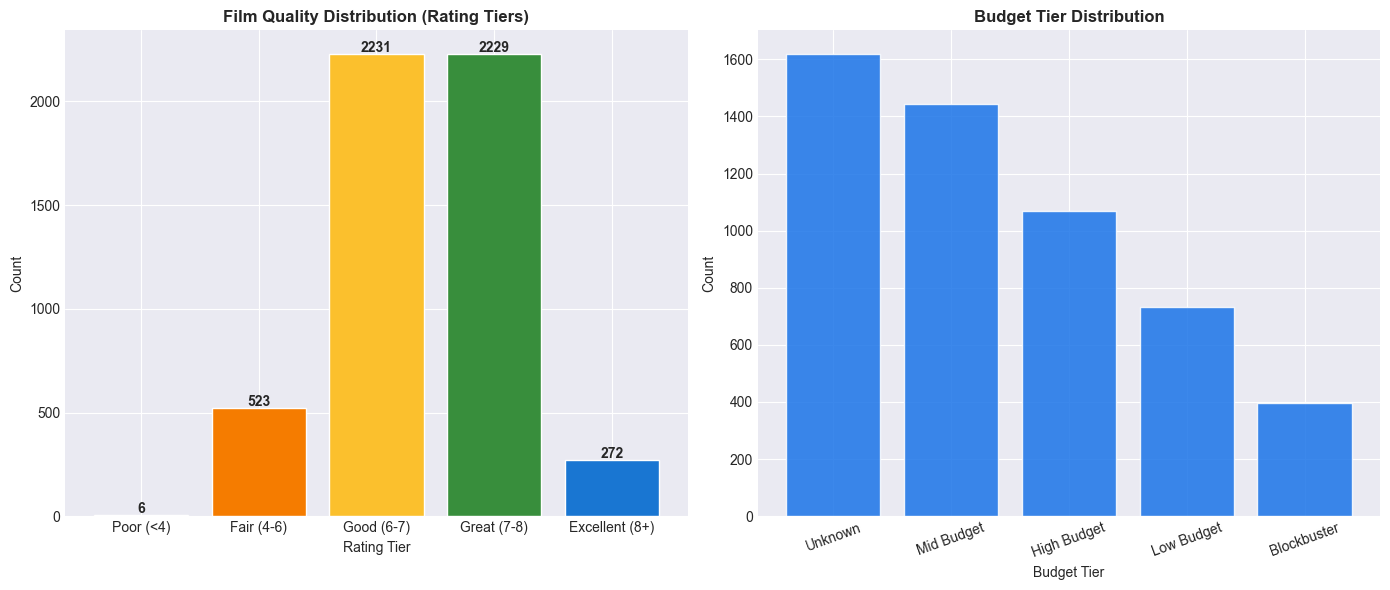

In [ ]:
# Rating tier & budget tier
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rt = df["rating_tier"].value_counts().sort_index()
axes[0].bar(rt.index.astype(str), rt.values,
    color=["#d32f2f","#f57c00","#fbc02d","#388e3c","#1976d2"], edgecolor="white")
axes[0].set_title("Film Quality Distribution (Rating Tiers)", fontweight="bold")
axes[0].set_xlabel("Rating Tier"); axes[0].set_ylabel("Count")
for i, v in enumerate(rt.values):
    axes[0].text(i, v+10, str(v), ha="center", fontweight="bold")

bt = df["budget_tier"].value_counts()
axes[1].bar(bt.index.astype(str), bt.values, color="#1a73e8", alpha=0.85, edgecolor="white")
axes[1].set_title("Budget Tier Distribution", fontweight="bold")
axes[1].set_xlabel("Budget Tier"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../exports/fig_03_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

**Poor (6 movies) :**

Our `vote_count >= 10` filter perfectly cleaned out poorly rated movies without an audience. The 6 remaining movies with rating < 4 are genuinely bad films.

**Good + Great (84.8% of the dataset) :**

The vast majority of movies fall between 6 and 8, perfectly aligning with our average of 6.83. Highly symmetric distribution between Good and Great (nearly identical: 2,231 vs. 2,229), confirming that 6.83 is truly the median of the dataset.

**Excellent (272 movies, 5.2%) :**

True masterpieces are genuinely rare >>> these will serve as the premium recommendations in our system.

**Fair (523 movies, 9.9%) :**

Decent movies, but below average—useful for diversifying recommendations.

**Unknown (30.4%) :**

1 out of 3 movies has no declared budget, mainly independent, foreign, or older films. These will be excluded from the Power BI financial analysis.

**Mid Budget (27.4%) :**

Movies between $5M and $30M—the core of the movie industry ("Comedies, Thrillers, Dramas").

**High Budget (20.2%) :**

Movies between $30M and $100M—major productions.

**Low Budget (14.1%) :**

Movies under $5M—independent cinema, auteur films, often featuring the best rating-to-budget ratios.

**Blockbuster (7.6%) :**

400 movies with a budget > $100M (Marvel, Disney, major animated films). These generate the highest revenue and popularity.

**Budget vs. Quality Correlation ?**

The "Blockbuster Paradox" : higher budgets yield higher revenues, but not necessarily better ratings. This will be a key focus of our Power BI financial analysis.

# 6. Multivariate EDA <a id="6-multivariate-eda" name="6-multivariate-eda"></a>

In [ ]:
# Genre explosion for multivariate analysis:
# We cannot analyze by genre if everything is in a single cell, for example df["genre"] = "Action, Thriller, Drama".
# Therefore, we need to explode each movie into as many rows as it has genres.
genre_rows = []
for _, row in df.iterrows():
    for g in str(row["genres"]).split(","):
        g = g.strip()
        if g:
            genre_rows.append({
                "title": row["title"], "genre": g,
                "vote_average": row["vote_average"], "vote_count": row["vote_count"],
                "runtime": row["runtime"], "budget": row["budget"], "revenue": row["revenue"],
                "release_year": row["release_year"], "release_decade": row["release_decade"],
                "popularity": row["popularity"], "weighted_rating": row["weighted_rating"],
                "director": row["director"], "production_countries": row["production_countries"],
            })
df_ge = pd.DataFrame(genre_rows)

# Average rating per genre
genre_stats = df_ge.groupby("genre").agg(
    total_films=("title","count"),
    avg_rating=("vote_average","mean"),
    median_rating=("vote_average","median"),
    avg_votes=("vote_count","mean"),
    avg_runtime=("runtime","mean"),
    avg_popularity=("popularity","mean"),
).round(2).sort_values("avg_rating", ascending=False)

print("Genre Statistics (sorted by avg rating):")
display(genre_stats.head(15))

Genre Statistics (sorted by avg rating):


,total_films,avg_rating,median_rating,avg_votes,avg_runtime,avg_popularity
genre,,,,,,
Documentary,196,7.24,7.30,324.53,103.49,3.21
Animation,572,7.23,7.30,2906.96,91.13,9.57
History,341,7.18,7.20,1885.67,132.10,5.32
Drama,2342,7.14,7.26,2377.26,117.36,6.32
Music,287,7.08,7.06,1062.12,108.81,4.92
War,278,7.08,7.13,2029.65,127.69,5.22
Romance,839,6.97,7.00,2129.75,111.67,6.69
Crime,807,6.95,6.96,2890.34,114.24,7.31
Family,635,6.92,6.95,3195.45,95.06,9.04


**Documentary and historical films** generally have the highest ratings > niche audience.

**Horror and action films** often have the lowest ratings > broader but less demanding audience.

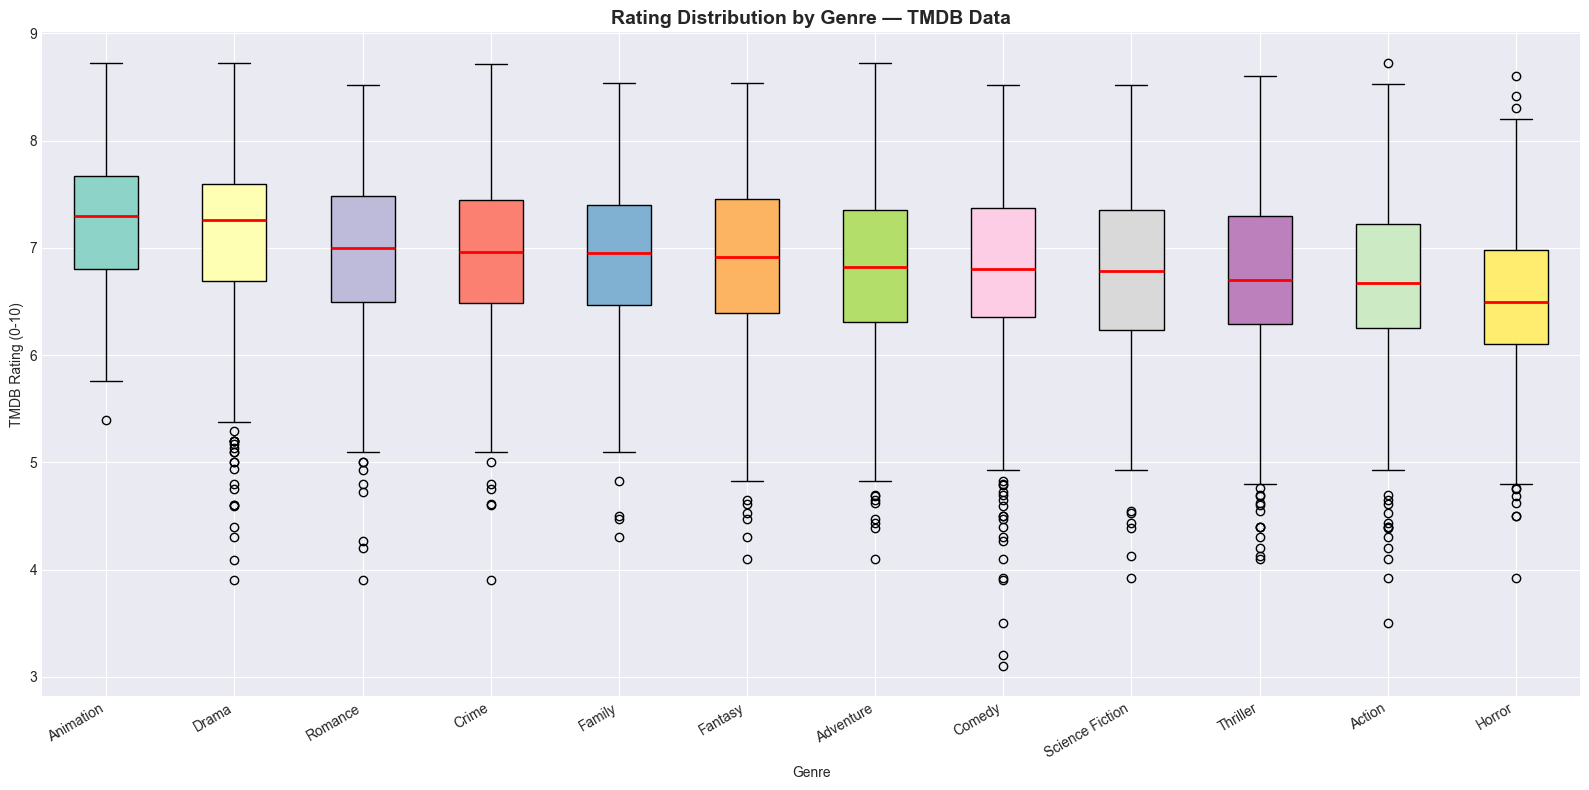

In [ ]:
# Boxplot: Rating by genre
top_genres = genre_counts.head(12).index.tolist()
df_top = df_ge[df_ge["genre"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(16, 8))
genre_order = df_top.groupby("genre")["vote_average"].median().sort_values(ascending=False).index
df_top_sorted = df_top[df_top["genre"].isin(genre_order)]

bp_data = [df_top_sorted[df_top_sorted["genre"]==g]["vote_average"].values for g in genre_order]
bp = ax.boxplot(bp_data, labels=genre_order, patch_artist=True, notch=False,
                medianprops=dict(color="red", linewidth=2))
colors = plt.cm.Set3(np.linspace(0, 1, len(genre_order)))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

ax.set_title("Rating Distribution by Genre — TMDB Data", fontsize=14, fontweight="bold")
ax.set_xlabel("Genre"); ax.set_ylabel("TMDB Rating (0-10)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../exports/fig_04_genre_rating_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


**Animation :**

Median ~7.3. Narrow box; lower whisker ~5.3. Animated films are consistently good studios like Disney and Studio Ghibli pull up the overall level. Only one low outlier around ~5.3, almost no bad movies in Animation.

**Drama :**

Most reliable. Median = 7.3, medium box width. Outliers : many low outliers. While the median matches Animation, the box is wider with many low outliers (4.0–5.0). This is expected since Drama is the most common genre, leading to higher variance.

**Crime + Romance :**

Crime is underrated with a very high median and few outliers, crime thrillers attract a demanding audience. High ratings for Romance suggest these films are generally well-received by their targeted audience.

**Comedy :**

Very wide box; outliers extend down to 3, showing high rating variability.

**Horror :**

The most extreme genre—outliers on both sides and a very wide box. Films tend to be either terrible or excellent.

**Action + Thriller + Science Fiction :**

Wide boxes with a lower median across all three mainstream commercial genres > a broader audience often translates to less demanding overall ratings.

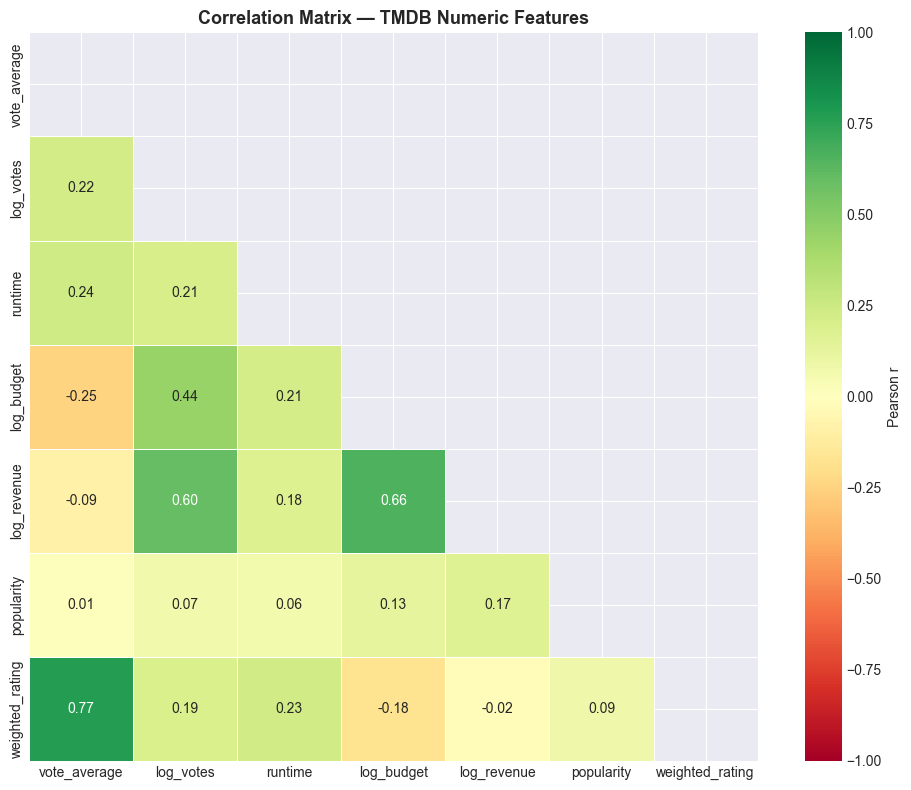


 Key correlations with vote_average:
vote_average       1.00
weighted_rating    0.77
runtime            0.24
log_votes          0.22
popularity         0.01
log_revenue       -0.09
log_budget        -0.25


In [ ]:
# Correlation heatmap
num_cols = ["vote_average","vote_count","runtime","budget","revenue","popularity","weighted_rating","n_genres"]
df_corr = df[num_cols].copy()
df_corr["log_votes"]   = np.log10(df_corr["vote_count"] + 1)
df_corr["log_budget"]  = np.log10(df_corr["budget"].replace(0, np.nan))
df_corr["log_revenue"] = np.log10(df_corr["revenue"].replace(0, np.nan))

corr = df_corr[["vote_average","log_votes","runtime","log_budget","log_revenue","popularity","weighted_rating"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1, center=0,
            cbar_kws={"label":"Pearson r"})
ax.set_title("Correlation Matrix — TMDB Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../exports/fig_05_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Key correlations with vote_average:")
print(corr["vote_average"].sort_values(ascending=False).to_string())

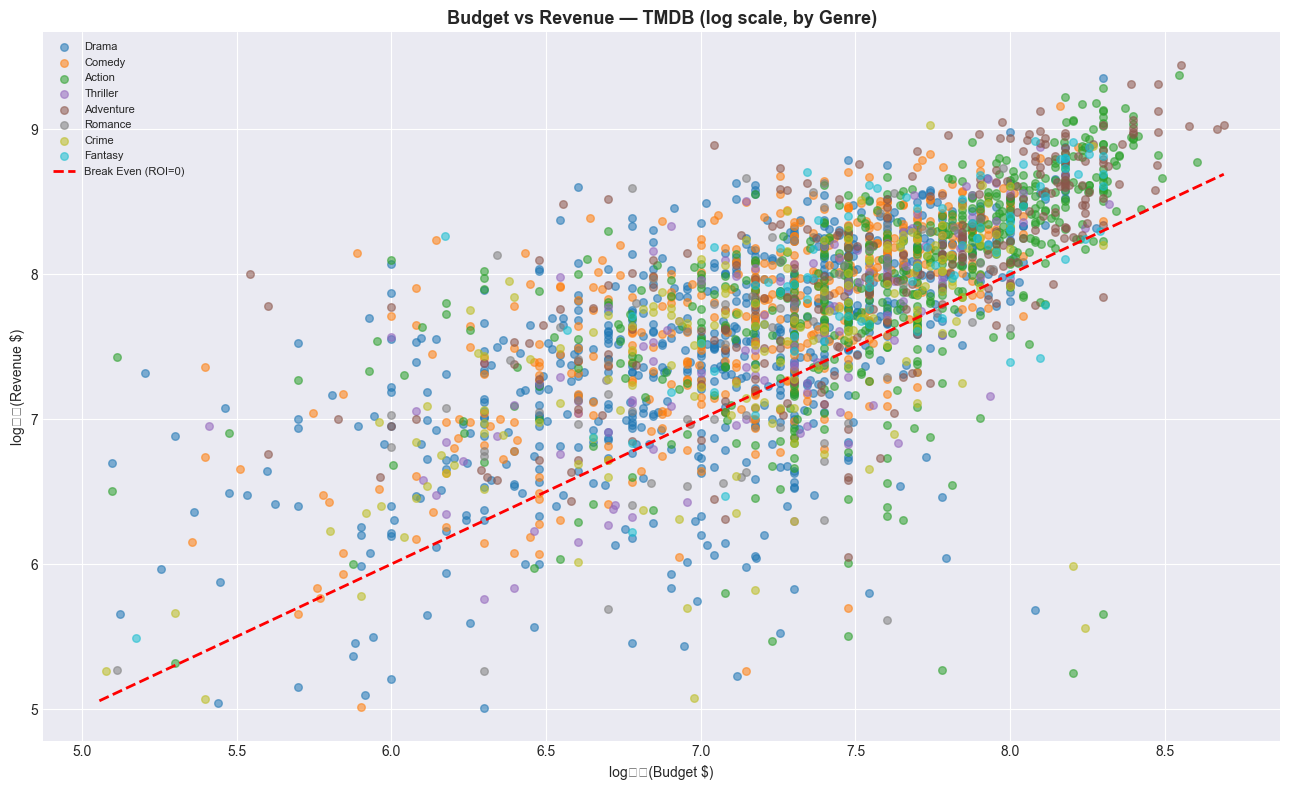

In [ ]:
# Budget vs Revenue scatter
df_br = df[(df["budget"]>100_000) & (df["revenue"]>100_000)].copy()
df_br["log_budget"]  = np.log10(df_br["budget"])
df_br["log_revenue"] = np.log10(df_br["revenue"])

fig, ax = plt.subplots(figsize=(13, 8))
top8g = genre_counts.head(8).index.tolist()
colors_g = plt.cm.tab10(np.linspace(0, 1, 8))
for i, g in enumerate(top8g):
    mask = df_br["primary_genre"] == g
    ax.scatter(df_br[mask]["log_budget"], df_br[mask]["log_revenue"],
               alpha=0.55, label=g, color=colors_g[i], s=30)
x_r = np.linspace(df_br["log_budget"].min(), df_br["log_budget"].max(), 100)
ax.plot(x_r, x_r, "r--", lw=2, label="Break Even (ROI=0)")
ax.set_title("Budget vs Revenue — TMDB (log scale, by Genre)", fontsize=13, fontweight="bold")
ax.set_xlabel("log₁₀(Budget $)"); ax.set_ylabel("log₁₀(Revenue $)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../exports/fig_06_budget_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

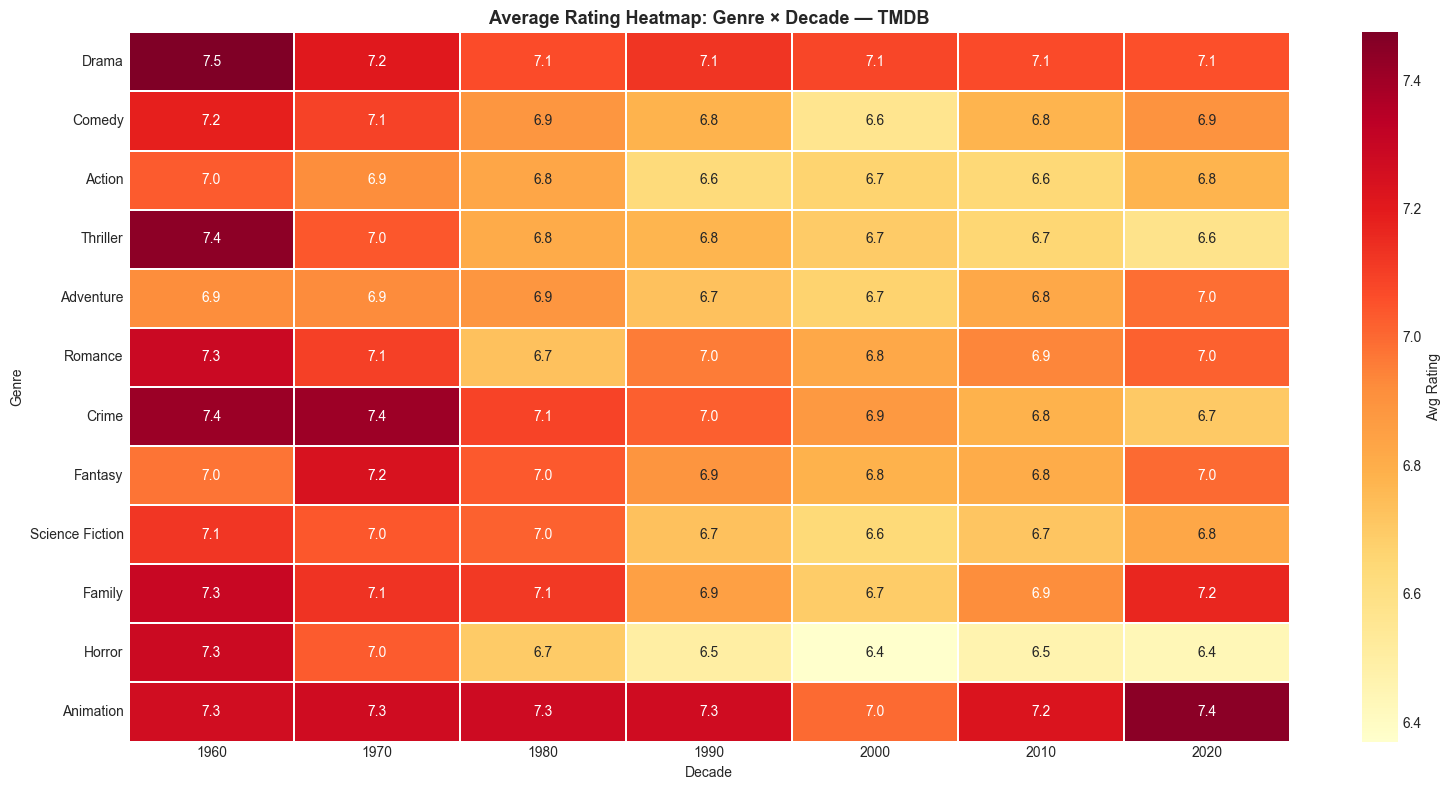

In [ ]:
# Genre × Decade heatmap
pivot = df_ge.groupby(["release_decade","genre"])["vote_average"].mean().unstack()
top_g = genre_counts.head(12).index.tolist()
pivot = pivot[[g for g in top_g if g in pivot.columns]]
pivot = pivot[pivot.index >= 1960].dropna(how="all")

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot.T, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=ax, linewidths=0.3, cbar_kws={"label":"Avg Rating"})
ax.set_title("Average Rating Heatmap: Genre × Decade — TMDB", fontsize=13, fontweight="bold")
ax.set_xlabel("Decade"); ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("../exports/fig_07_heatmap_genre_decade.png", dpi=150, bbox_inches="tight")
plt.show()


# 7. Advanced EDA — Trends & Deep Dives <a id="7-advanced-eda" name="7-advanced-eda"></a>

TOP 10 FILMS — IMDb-style Weighted Rating:


,title,release_year,primary_genre,vote_average,vote_count,weighted_rating,director
1,The Shawshank Redemption,1994,Drama,8.72,30151,8.54,Frank Darabont
2,The Godfather,1972,Drama,8.69,22778,8.46,Francis Ford Coppola
3,The Dark Knight,2008,Action,8.53,35532,8.39,Christopher Nolan
4,Pulp Fiction,1994,Thriller,8.48,30025,8.33,Quentin Tarantino
5,The Lord of the Rings: The Return of the King,2003,Adventure,8.50,26353,8.32,Peter Jackson
6,Forrest Gump,1994,Comedy,8.46,29561,8.30,Robert Zemeckis
7,Schindler's List,1993,Drama,8.57,17336,8.30,Steven Spielberg
8,Fight Club,1999,Drama,8.44,31827,8.29,David Fincher
9,Spirited Away,2001,Animation,8.53,18183,8.28,Hayao Miyazaki
10,Parasite,2019,Comedy,8.49,20455,8.27,Bong Joon Ho


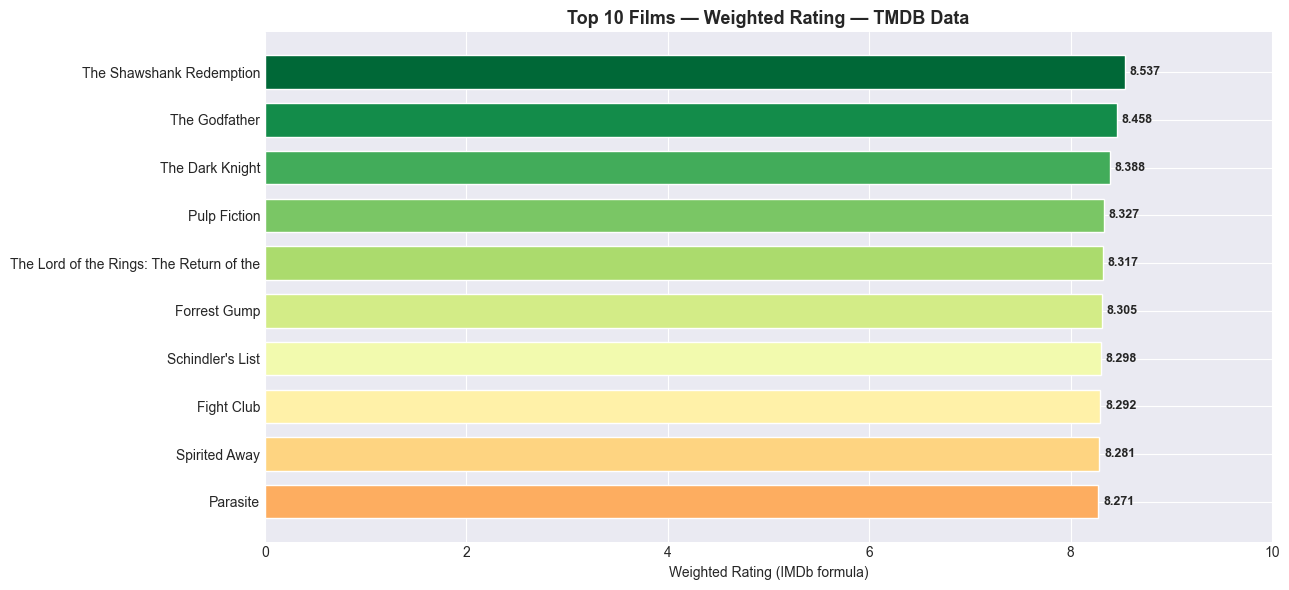

In [ ]:
# Top 10 movies by weighted rating
top10 = df.nlargest(10, "weighted_rating")[
    ["title","release_year","primary_genre","vote_average","vote_count","weighted_rating","director"]]
top10 = top10.reset_index(drop=True)
top10.index += 1
print("TOP 10 FILMS — IMDb-style Weighted Rating:")
display(top10)

fig, ax = plt.subplots(figsize=(13, 6))
colors_t = plt.cm.RdYlGn(np.linspace(0.3, 1.0, 10))
bars = ax.barh(top10["title"].str[:40], top10["weighted_rating"],
               color=colors_t[::-1], edgecolor="white", height=0.7)
ax.set_xlabel("Weighted Rating (IMDb formula)")
ax.set_title("Top 10 Films — Weighted Rating — TMDB Data", fontsize=13, fontweight="bold")
ax.set_xlim(0, 10); ax.invert_yaxis()
for bar, val in zip(bars, top10["weighted_rating"]):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../exports/fig_09_top10.png", dpi=150, bbox_inches="tight")
plt.show()

 TOP DIRECTORS (min 3 films, by avg rating):


,films,avg_rating,avg_votes,total_revenue,avg_popularity
director,,,,,
Tosca Musk,3,8.38,1691.33,0,4.95
Charlie Chaplin,5,8.19,2865.60,26500000,6.73
Sergio Leone,6,8.11,5105.00,79280118,10.65
Paul Dugdale,4,8.10,257.75,15,2.89
Akira Kurosawa,13,8.05,1328.31,135548320,6.00
Yasujirō Ozu,3,8.03,664.67,0,3.52
Kazuya Tsurumaki,3,8.02,1282.33,134567049,7.73
Isao Takahata,3,7.98,3222.33,25681898,3.32
Satoshi Kon,4,7.97,2113.25,2275632,7.33


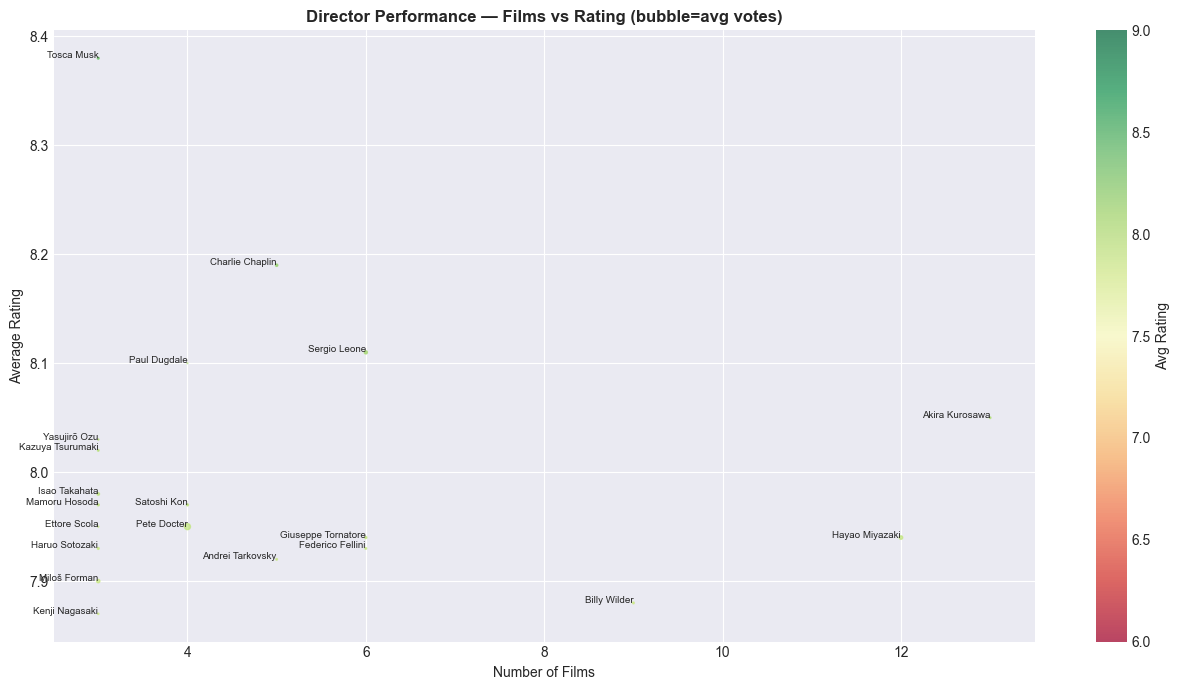

In [ ]:
# Director analysis
dir_stats = df.groupby("director").agg(
    films=("id","count"), avg_rating=("vote_average","mean"),
    avg_votes=("vote_count","mean"), total_revenue=("revenue","sum"),
    avg_popularity=("popularity","mean")
).round(2)
dir_stats = dir_stats[dir_stats["films"] >= 3].sort_values("avg_rating", ascending=False)

print(" TOP DIRECTORS (min 3 films, by avg rating):")
display(dir_stats.head(20))

fig, ax = plt.subplots(figsize=(13, 7))
top_d = dir_stats.head(20).reset_index()
scatter = ax.scatter(top_d["films"], top_d["avg_rating"],
    s=top_d["avg_votes"]/1000, alpha=0.7,
    c=top_d["avg_rating"], cmap="RdYlGn", vmin=6, vmax=9)
for _, row in top_d.iterrows():
    ax.annotate(row["director"], (row["films"], row["avg_rating"]), fontsize=7, ha="right")
plt.colorbar(scatter, ax=ax, label="Avg Rating")
ax.set_xlabel("Number of Films"); ax.set_ylabel("Average Rating")
ax.set_title("Director Performance — Films vs Rating (bubble=avg votes)", fontweight="bold")
plt.tight_layout()
plt.savefig("../exports/fig_10_directors.png", dpi=150, bbox_inches="tight")
plt.show()


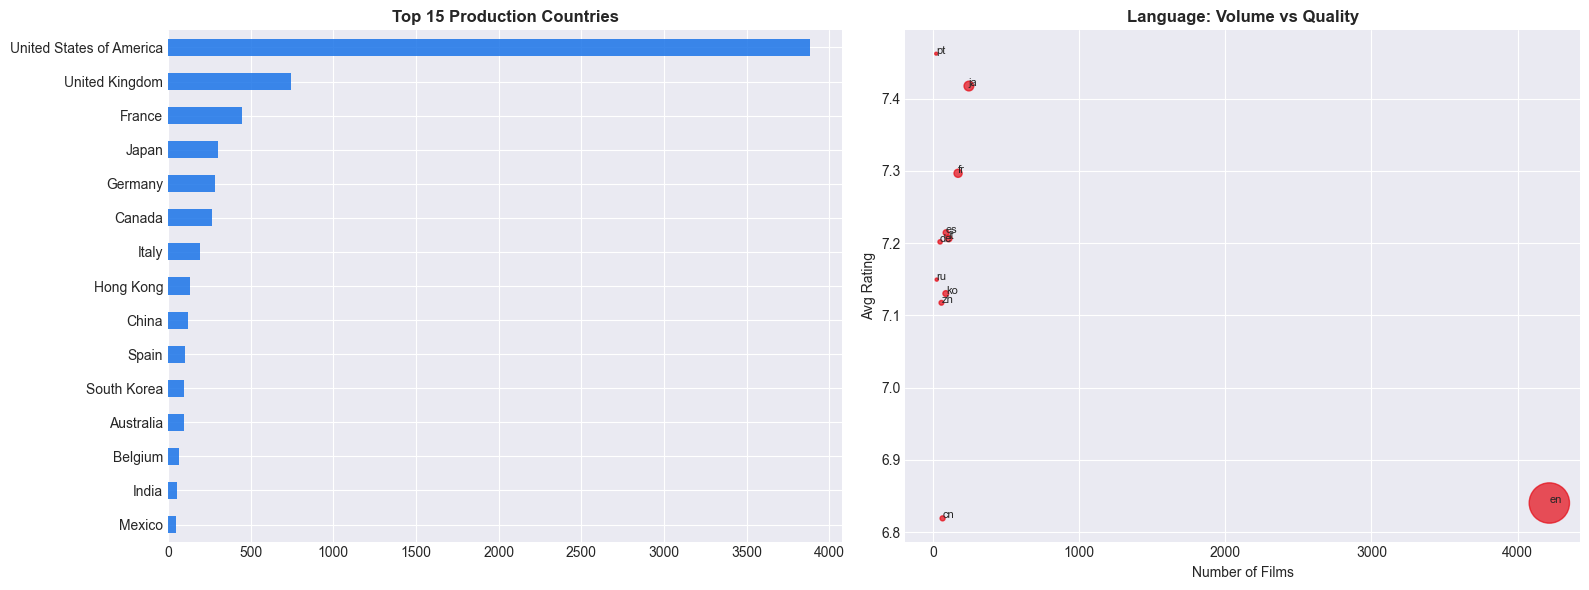

In [ ]:
# Production countries
ctry_list = []
for c in df["production_countries"].dropna():
    for x in str(c).split(","):
        x = x.strip()
        if x: ctry_list.append(x)
ctry_counts = pd.Series(ctry_list).value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ctry_counts.plot(kind="barh", ax=axes[0], color="#1a73e8", alpha=0.85)
axes[0].set_title("Top 15 Production Countries", fontweight="bold")
axes[0].invert_yaxis()

# Language vs rating scatter
lang_stats = df.groupby("original_language").agg(
    count=("id","count"), avg_rating=("vote_average","mean")).reset_index()
lang_stats = lang_stats[lang_stats["count"] >= 20]
axes[1].scatter(lang_stats["count"], lang_stats["avg_rating"],
    s=lang_stats["count"]/5, alpha=0.7, color="#e50914")
for _, row in lang_stats.iterrows():
    axes[1].annotate(row["original_language"], (row["count"], row["avg_rating"]), fontsize=8)
axes[1].set_xlabel("Number of Films"); axes[1].set_ylabel("Avg Rating")
axes[1].set_title("Language: Volume vs Quality", fontweight="bold")

plt.tight_layout()
plt.savefig("../exports/fig_11_countries_languages.png", dpi=150, bbox_inches="tight")
plt.show()


# 8. Business problems & Solutions <a id="8-business-problems" name="8-business-problems"></a>

**Problem 1 : Choice Overload**

* **Finding :** 5,500 movies in the catalog with no selection guidance.
* **Impact :** Users abandon the platform due to decision fatigue.
* **Solution :** Content-based recommendation system (TF-IDF + cosine similarity).

**Problem 2 : Lack of Diversity**

* **Finding :** Drama (23.6%) + Comedy (15%) dominate the catalog.
* **Impact :** Niche movies (Animation, History, Documentary) remain invisible.
* **Solution :** Weighted recommendations to diversify suggested genres.

**Problem 3 : Low-Quality Movies**

* **Finding :** 15% of movies have a rating < 5.0; 529 movies fall into "Fair" or "Poor" tiers.
* **Impact :** Poor user experience if a disappointing movie is recommended.
* **Solution :** `weighted_rating` filter (IMDb formula) with a configurable minimum threshold.

**Problem 4 : Absence of Personalization**

* **Finding :** No user history or profile data present in current dataset.
* **Impact :** Generic recommendations that fail to match individual tastes.
* **Solution :** Interactive Streamlit UI capturing user preferences (genres, actors, directors).

**Problem 5 : Underexposed Foreign Movies**

* **Finding :** 30%+ non-English films suffer from a small audience reach (English bias = 78.6%).
* **Impact :** Loss of potential revenue and cultural diversity.
* **Solution :** Language filter in Streamlit + dedicated highlighting of Japanese (ja), Korean (ko), and French (fr) films.

**Problem 6 : Unused Financial Data**

* **Finding :** Budget and revenue available for 66–71% of movies but remaining unanalyzed.
* **Impact :** Inability to evaluate profitability across genres or studios.
* **Solution :** Power BI Dashboard covering ROI, profit, budget tiers, and break-even analysis.

**Problem 7 : Popularity vs. Quality Confusion**

* **Finding :** Correlation between `popularity` and `vote_average` is 0.01 (almost non-existent).
* **Impact :** Trending movies can be mediocre, leading to misleading recommendations.
* **Solution :** Decoupled metrics tracking `popularity_tier` (trends) alongside `weighted_rating` (quality).

______

**Global Overview**

This block quantifies each business problem with real figures pulled from the dataset—the data speaks for itself !

**Problem 1 :** Choice Overload

In [ ]:
print(f"Problem 1 — Catalog too large to browse manually:")
print(f"  Total films in catalog: {len(df):,}")
print(f"  Without recommendation: users browse ∞ films")

Problem 1 — Catalog too large to browse manually:
  Total films in catalog: 5,261
  Without recommendation: users browse ∞ films


**Problem 2** : Lack of Diversity

In [ ]:
top3_genres = genre_counts.head(3)
pct = top3_genres.sum() / genre_counts.sum() * 100
print(f"  Top 3 genres ({', '.join(top3_genres.index)}) = {pct:.1f}% of catalog")

  Top 3 genres (Drama, Comedy, Action) = 36.6% of catalog


**Problem 3 :** Low-Quality Movies

In [ ]:
poor = (df["vote_average"] < 5.0).sum()
print(f"  Films rated < 5.0: {poor:,} ({poor/len(df)*100:.1f}%)")

  Films rated < 5.0: 54 (1.0%)


**Problème 4 :** Linguistic Diversity

In [ ]:
non_eng = (df["original_language"] != "en").sum()
print(f"  Non-English films: {non_eng:,} ({non_eng/len(df)*100:.1f}%)")

  Non-English films: 1,044 (19.8%)


**Problème 5 :** Popularity ≠ Quality

In [ ]:
corr_pop_rating = df["popularity"].corr(df["vote_average"])
print(f"  Correlation popularity ↔ rating: {corr_pop_rating:.3f}")
print(f"  → Weak link — popularity does NOT predict quality")

  Correlation popularity ↔ rating: 0.010
  → Weak link — popularity does NOT predict quality


**Problème 6 :** ROI by Genre

In [ ]:
roi_genre = df[df["roi"].notna()]\
            .groupby("primary_genre")["roi"]\
            .mean()\
            .sort_values(ascending=False)
print(f"\nProblem 6 — ROI by genre (best investment):")
print(roi_genre.head(8).round(2).to_string())


Problem 6 — ROI by genre (best investment):
primary_genre
Documentary   13.92
Horror         9.45
TV Movie       7.40
Animation      6.34
Adventure      6.08
Comedy         5.34
Family         5.16
Romance        4.85


**Final Summary : The 4 tools of our solution**

Recommendation engine → TF-IDF + KNN engine

Filters → Streamlit (genre, language, runtime)

Weighted rating → IMDb formula

KPIs → Power BI dashboard

# 9. Feature Engineering <a id="9-feature-engineering" name="9-feature-engineering"></a>

In [ ]:
# Text features for TF-IDF
def clean_text(t):
    if pd.isna(t): return ""
    return re.sub(r"[^a-zA-Z0-9 ]", " ", str(t).lower()).strip()

df["genres_clean"]   = df["genres"].apply(
    lambda x: " ".join([g.strip().replace(" ","") for g in str(x).split(",")]) if pd.notna(x) else "")
df["director_clean"] = df["director"].apply(
    lambda x: str(x).replace(" ","").lower() if pd.notna(x) else "")
df["cast_clean"]     = df["cast"].apply(
    lambda x: " ".join([a.strip().replace(" ","").lower() for a in str(x).split(",")[:5]])
              if pd.notna(x) else "")
df["overview_clean"] = df["overview"].apply(clean_text)
df["tagline_clean"]  = df["tagline"].apply(clean_text)

# Weighted soup — genres 4x, director 3x, cast 2x, overview 2x, tagline 1x
df["soup"] = (
    df["genres_clean"]   * 4 + " " +
    df["director_clean"] * 3 + " " +
    df["cast_clean"]     * 2 + " " +
    df["overview_clean"] * 2 + " " +
    df["tagline_clean"]
)

# Normalised numeric features
scaler = MinMaxScaler()
num_feats = ["vote_average","vote_count","runtime","popularity"]
df[["rating_norm","votes_norm","runtime_norm","pop_norm"]] = scaler.fit_transform(
    df[num_feats].fillna(0))
df["year_norm"] = ((df["release_year"] - df["release_year"].min()) /
                   (df["release_year"].max() - df["release_year"].min() + 1)).fillna(0)

print(" Feature Engineering Summary:")
print(f"  Text soup avg length:  {df['soup'].str.len().mean():.0f} chars")
print(f"  Genres weight:         4x in soup")
print(f"  Director weight:       3x in soup")
print(f"  Cast weight:           2x in soup")
print(f"  Overview weight:       2x in soup")
print(f"  Normalised numerics:   {num_feats}")
print()
print("Sample soup for 'Star Wars':")
sample = df[df["title"].str.lower() == "star wars"]
if len(sample):
    print(sample["soup"].values[0][:300])

 Feature Engineering Summary:
  Text soup avg length:  825 chars
  Genres weight:         4x in soup
  Director weight:       3x in soup
  Cast weight:           2x in soup
  Overview weight:       2x in soup
  Normalised numerics:   ['vote_average', 'vote_count', 'runtime', 'popularity']

Sample soup for 'Star Wars':
Adventure Action ScienceFictionAdventure Action ScienceFictionAdventure Action ScienceFictionAdventure Action ScienceFiction georgelucasgeorgelucasgeorgelucas markhamill harrisonford carriefisher petercushing alecguinnessmarkhamill harrisonford carriefisher petercushing alecguinness princess leia is


In [ ]:
# TF-IDF matrix
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)
tfidf_matrix = tfidf.fit_transform(df["soup"].fillna(""))
df = df.reset_index(drop=True)
title_to_idx = pd.Series(df.index, index=df["title"].str.lower())

print(f" TF-IDF Matrix built:")
print(f"   Shape:         {tfidf_matrix.shape}")
print(f"   Vocabulary:    {len(tfidf.vocabulary_):,} terms")
print(f"   Sparsity:      {1 - tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.4%}")
print(f"   Title index:   {len(title_to_idx):,} entries")

 TF-IDF Matrix built:
   Shape:         (5261, 20000)
   Vocabulary:    20,000 terms
   Sparsity:      99.8097%
   Title index:   5,261 entries


# 10. Model Selection Strategy <a id="10-model-selection" name="10-model-selection"></a>

## Primary Model Selected : TF-IDF + Cosine Similarity

WildFlix is a new platform no user history is available.
Content-based filtering is the ideal solution for launching.
As user data accumulates, a hybrid model will take over.

## Model Roadmap :

Phase 1 : Launch (Current)

* TF-IDF + Cosine Similarity

* Weighted Rating (quality filter)

* Popularity (home page fallback)

Phase 2 : Growth (User Data Available)

* Item-Based KNN (collaborative filtering)

* User history tracking

Phase 3 : Maturity (Complete Profiles)

* Hybrid model

* Maximum personalization

## Why TF-IDF + Cosine in Phase 1 ?

* No Cold Start : works immediately for the very first user without requiring prior data.

* Explainable : enables clear reasoning for why a movie is recommended.

* Fast : computes in milliseconds across all 5,261 movies.

* Robust : entirely independent of user interaction data.

# 11. Content-Based Filtering — TF-IDF + Cosine Similarity <a id="11-content-based" name="11-content-based"></a>

In [ ]:
def fuzzy_match(title, title_to_idx):
    """Find best match for a title (case-insensitive, partial match)."""
    tl = title.lower().strip()
    if tl in title_to_idx.index:
        return tl
    # Partial match
    matches = [t for t in title_to_idx.index if tl in t or t in tl]
    if matches:
        return sorted(matches, key=lambda x: abs(len(x) - len(tl)))[0]
    # Token match
    for tok in tl.split():
        if len(tok) > 3:
            matches = [t for t in title_to_idx.index if tok in t]
            if matches:
                return sorted(matches, key=lambda x: abs(len(x)-len(tl)))[0]
    return None

def content_recommendations(title, n=5, genre_filter=None,
                              min_year=None, max_runtime=None,
                              min_rating=None, language=None):
    """
    Content-based recommendations using TF-IDF cosine similarity.

    Parameters:
    -----------
    title        : Input movie title
    n            : Number of recommendations (default 5)
    genre_filter : Filter by genre (optional)
    min_year     : Minimum release year (optional)
    max_runtime  : Maximum runtime in minutes (optional)
    min_rating   : Minimum TMDB rating (optional)
    language     : Filter by original language (optional)
    """
    matched = fuzzy_match(title, title_to_idx)
    if matched is None:
        print(f"Movie not found: '{title}'")
        return None

    idx = title_to_idx[matched]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]

    # Cosine similarity
    sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    scored = df.copy()
    scored["_sim"] = sim
    scored = scored[scored.index != idx]

    # Apply filters
    if genre_filter:
        scored = scored[scored["genres"].str.contains(genre_filter, case=False, na=False)]
    if min_year:
        scored = scored[scored["release_year"] >= min_year]
    if max_runtime:
        scored = scored[scored["runtime"] <= max_runtime]
    if min_rating:
        scored = scored[scored["vote_average"] >= min_rating]
    if language:
        scored = scored[scored["original_language"] == language]

    results = scored.nlargest(n, "_sim")[
        ["title","release_year","primary_genre","vote_average","vote_count",
         "runtime","director","_sim","poster_path"]
    ].reset_index(drop=True)
    results.index += 1
    results.columns = ["Title","Year","Genre","Rating","Votes","Runtime (min)","Director","Similarity","Poster"]
    return results, df.iloc[idx]

print(" Content-based recommender ready")


 Content-based recommender ready


In [ ]:
#  DEMO : 10 test cases
test_cases = [
    ("Star Wars",          {}),
    ("Forrest Gump",       {"min_rating": 7.0}),
    ("The Dark Knight",    {"genre_filter": "Action"}),
    ("Inception",          {"min_year": 2010, "max_runtime": 130}),
    ("Finding Nemo",       {"genre_filter": "Animation"}),
    ("Pulp Fiction",       {"genre_filter": "Crime"}),
    ("The Godfather",      {"min_rating": 8.0}),
    ("Interstellar",       {"genre_filter": "Science Fiction"}),
    ("Toy Story",          {"max_runtime": 100}),
    ("The Silence of the Lambs", {"genre_filter": "Thriller"}),
]

for movie, filters in test_cases:
    print(f"\n{'='*65}")
    print(f" Input: '{movie}'  |  Filters: {filters or 'None'}")
    print(f"{'='*65}")
    result = content_recommendations(movie, n=5, **filters)
    if result:
        recs, inp = result
        print(f"  Because you liked: {inp['title']} ({int(inp['release_year'])} |  {inp['vote_average']:.1f})")
        print(recs.drop(columns=["Poster"]).to_string())


 Input: 'Star Wars'  |  Filters: None
  Because you liked: Star Wars (1977 |  8.2)
                                          Title  Year      Genre  Rating  Votes  Runtime (min)          Director  Similarity
1                       The Empire Strikes Back  1980  Adventure    8.39  18286            124    Irvin Kershner        0.48
2                            Return of the Jedi  1983  Adventure    7.91  16826            132  Richard Marquand        0.40
3                  Star Wars: The Force Awakens  2015  Adventure    7.25  20441            136       J.J. Abrams        0.36
4                      Star Wars: The Last Jedi  2017  Adventure    6.75  16238            152      Rian Johnson        0.30
5  Star Wars: Episode III - Revenge of the Sith  2005  Adventure    7.46  14834            140      George Lucas        0.28

 Input: 'Forrest Gump'  |  Filters: {'min_rating': 7.0}
  Because you liked: Forrest Gump (1994 |  8.5)
                    Title  Year   Genre  Rating  Votes  Runti

# 12. KNN Collaborative Filtering <a id="12-knn" name="12-knn"></a>

In [ ]:
# We simulate users rating movies because WILDFLIX does not have real users yet.
# Our solution is to simulate ratings using random values based on "vote_average".

np.random.seed(42)
N_USERS = 500
user_ids = [f"U{i:04d}" for i in range(1, N_USERS+1)]

# Sample movies for each user (simulate watch history)
movie_ids = df["id"].tolist()
user_movie_ratings = []
for uid in user_ids:
    n_watched = np.random.randint(10, 60)
    watched = np.random.choice(movie_ids, size=min(n_watched, len(movie_ids)), replace=False)
    for mid in watched:
        movie_row = df[df["id"] == mid]
        if len(movie_row):
            base = float(movie_row["vote_average"].values[0])
            simulated_rating = float(np.clip(np.random.normal(base, 0.8), 1.0, 10.0))
            user_movie_ratings.append({
                "user_id": uid, "movie_id": mid, "rating": round(simulated_rating, 1)
            })

df_ratings = pd.DataFrame(user_movie_ratings)

# User-item matrix
user_item = df_ratings.pivot_table(index="user_id", columns="movie_id", values="rating", fill_value=0)
print(f" User-Item matrix: {user_item.shape}")
print(f"   Users:     {user_item.shape[0]:,}")
print(f"   Movies:    {user_item.shape[1]:,}")
print(f"   Sparsity:  {1 - df_ratings.shape[0]/(user_item.shape[0]*user_item.shape[1]):.3%}")

# KNN on items
user_item_sparse = csr_matrix(user_item.values)
knn_model = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=20)
knn_model.fit(user_item_sparse.T)

mid_to_idx = {mid: i for i, mid in enumerate(user_item.columns)}
idx_to_mid = {i: mid for mid, i in mid_to_idx.items()}
print(f"\n KNN model trained (cosine similarity, item-based)")

 User-Item matrix: (500, 5048)
   Users:     500
   Movies:    5,048
   Sparsity:  99.330%

 KNN model trained (cosine similarity, item-based)


In [ ]:
def knn_recommendations(movie_title, n=5):
    """KNN item-based collaborative recommendations."""
    matched = fuzzy_match(movie_title, title_to_idx)
    if not matched: return None
    idx = title_to_idx[matched]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]
    movie_id = df.iloc[idx]["id"]

    if movie_id not in mid_to_idx:
        print(f"  Movie not in rating matrix — using content-based fallback")
        return content_recommendations(movie_title, n=n)

    kidx = mid_to_idx[movie_id]
    dists, indices = knn_model.kneighbors(user_item_sparse.T[kidx], n_neighbors=n+1)

    neighbor_ids = [idx_to_mid[i] for i in indices.flatten() if i != kidx][:n]
    neighbor_sims = 1 - dists.flatten()[1:n+1]

    results = df[df["id"].isin(neighbor_ids)][
        ["id", "title", "release_year", "primary_genre", "vote_average", "runtime", "director"]
    ].copy()

    sim_map = dict(zip(neighbor_ids, neighbor_sims))
    results["knn_similarity"] = results["id"].map(sim_map)

    return results.drop(columns=["id"]).sort_values("knn_similarity", ascending=False).reset_index(drop=True)

print(" KNN Recommendations Demo:")
for movie in ["Star Wars", "Forrest Gump", "The Dark Knight"]:
    print(f"\n Input: {movie}")
    res = knn_recommendations(movie, n=5)
    if res is not None and not isinstance(res, tuple):
        print(res[["title", "primary_genre", "vote_average", "knn_similarity"]].to_string())

 KNN Recommendations Demo:

 Input: Star Wars
                      title primary_genre  vote_average  knn_similarity
0       Clash of the Titans     Adventure          6.90            0.51
1                    Tetris      Thriller          7.63            0.43
2   The Long Kiss Goodnight         Crime          6.60            0.43
3         Prayers for Bobby         Drama          8.06            0.43
4  Turtles All the Way Down         Drama          7.30            0.41

 Input: Forrest Gump
                               title primary_genre  vote_average  knn_similarity
0                           Fearless         Drama          7.51            0.55
1    Goosebumps 2: Haunted Halloween        Comedy          6.10            0.55
2                            Watcher        Horror          6.48            0.55
3  The Girl Who Believes in Miracles        Family          7.40            0.50
4                          Peter Pan     Adventure          7.14            0.48

 Input: The D

# 13. Hybrid Recommendation Engine <a id="13-hybrid" name="13-hybrid"></a>

In [ ]:
def hybrid_recommendations(title, user_id=None, n=5,
                           content_weight=0.65, collab_weight=0.35,
                           genre_filter=None, min_year=None,
                           max_runtime=None, min_rating=None):
    """
    Hybrid recommendation: content-based (TF-IDF) + collaborative (KNN).
    Optional user personalisation via favourite genre boost.
    """
    matched = fuzzy_match(title, title_to_idx)
    if not matched:
        print(f"Not found: {title}"); return None
    idx = title_to_idx[matched]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]

    # Content scores
    content_sim = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    # Collab scores
    collab_sim = np.zeros(len(df))
    movie_id = df.iloc[idx]["id"]
    if movie_id in mid_to_idx:
        kidx = mid_to_idx[movie_id]
        dists, indices = knn_model.kneighbors(
            user_item_sparse.T[kidx], n_neighbors=min(50, len(mid_to_idx)))
        for dist, i in zip(dists.flatten(), indices.flatten()):
            nb_id = idx_to_mid.get(i)
            if nb_id:
                nb_rows = df[df["id"] == nb_id].index
                if len(nb_rows):
                    collab_sim[nb_rows[0]] = 1 - dist

    # Hybrid score
    hybrid = content_weight * content_sim + collab_weight * collab_sim

    # User genre boost
    if user_id:
        user_ratings = df_ratings[df_ratings["user_id"] == user_id]
        if len(user_ratings) > 3:
            top_movies = user_ratings.nlargest(10, "rating")["movie_id"]
            fav_genres = []
            for mid in top_movies:
                row = df[df["id"]==mid]
                if len(row): fav_genres.extend(str(row["genres"].values[0]).split(","))
            top_genres = [g.strip() for g, _ in Counter(fav_genres).most_common(3)]
            for g in top_genres:
                mask = df["genres"].str.contains(g, case=False, na=False)
                hybrid[mask] *= 1.08

    scored = df.copy()
    scored["_hybrid"] = hybrid
    scored = scored[scored.index != idx]

    if genre_filter: scored = scored[scored["genres"].str.contains(genre_filter, case=False, na=False)]
    if min_year:     scored = scored[scored["release_year"] >= min_year]
    if max_runtime:  scored = scored[scored["runtime"] <= max_runtime]
    if min_rating:   scored = scored[scored["vote_average"] >= min_rating]

    results = scored.nlargest(n, "_hybrid")[
        ["title","release_year","primary_genre","vote_average","runtime","director","_hybrid","poster_path"]
    ].reset_index(drop=True)
    results.index += 1
    return results, df.iloc[idx]

print(" Hybrid Recommendations Demo:")
test_hybrid = [
    ("Star Wars", "U0001"), ("Forrest Gump", "U0042"), ("Inception", "U0100"),
    ("The Godfather", "U0200"), ("Finding Nemo", "U0300"),
]
for movie, uid in test_hybrid:
    print(f"\n '{movie}' | User: {uid}")
    print("-"*55)
    res = hybrid_recommendations(movie, user_id=uid, n=5)
    if res:
        recs, inp = res
        print(recs[["title","primary_genre","vote_average","_hybrid"]].to_string())

 Hybrid Recommendations Demo:

 'Star Wars' | User: U0001
-------------------------------------------------------
                          title primary_genre  vote_average  _hybrid
1       The Empire Strikes Back     Adventure          8.39     0.33
2            Return of the Jedi     Adventure          7.91     0.28
3  Star Wars: The Force Awakens     Adventure          7.25     0.25
4           Clash of the Titans     Adventure          6.90     0.24
5      Star Wars: The Last Jedi     Adventure          6.75     0.21

 'Forrest Gump' | User: U0042
-------------------------------------------------------
                  title primary_genre  vote_average  _hybrid
1     Letters to Juliet        Comedy          7.00     0.32
2  New York, I Love You        Comedy          5.94     0.29
3  Sleepless in Seattle        Comedy          6.70     0.24
4              Fearless         Drama          7.51     0.23
5     Love & Basketball        Comedy          7.34     0.23

 'Inception' | Use

# 14. Model Evaluation & Validation <a id="14-evaluation" name="14-evaluation"></a>

In [ ]:
# Metric 1: Genre consistency
def genre_consistency(input_title, recs_df):
    matched = fuzzy_match(input_title, title_to_idx)
    if not matched or recs_df is None: return 0
    idx = title_to_idx[matched]
    if isinstance(idx, pd.Series): idx = idx.iloc[0]
    inp_genres = set(str(df.iloc[idx]["genres"]).split(","))
    scores = []
    for _, row in recs_df.iterrows():
        rec_col = "Genre" if "Genre" in row.index else "primary_genre"
        genres_col = "genres" if "genres" in row.index else rec_col
        rec_g = set(str(row.get("Genre", row.get("primary_genre",""))).split(","))
        overlap = len(inp_genres & rec_g) / max(len(inp_genres), 1)
        scores.append(overlap)
    return np.mean(scores) if scores else 0


# Evaluate on top 30 popular films
top30 = df.nlargest(30, "vote_count")["title"].tolist()
consistency_scores = []
rating_scores = []
for t in top30:
    res = content_recommendations(t, n=5)
    if res:
        recs, _ = res
        consistency_scores.append(genre_consistency(t, recs))
        rating_scores.append(recs["Rating"].mean())

print(" CONTENT-BASED MODEL EVALUATION")
print("="*50)
print(f"  Tested on:              {len(top30)} popular films")
print(f"  Genre Consistency:      {np.mean(consistency_scores):.3f} (avg) | {np.min(consistency_scores):.3f} (min) | {np.max(consistency_scores):.3f} (max)")
print(f"  Avg Rec Rating:         {np.mean(rating_scores):.2f}")
print(f"  Dataset Avg Rating:     {df['vote_average'].mean():.2f}")
print(f"  Rating Uplift:          {np.mean(rating_scores) - df['vote_average'].mean():+.2f}")
print()

# Coverage
all_rec_titles = set()
for t in top30:
    res = content_recommendations(t, n=10)
    if res:
        recs, _ = res
        all_rec_titles.update(recs["Title"].tolist())
coverage = len(all_rec_titles) / len(df) * 100
print(f"  Catalog Coverage:       {coverage:.1f}% ({len(all_rec_titles)} unique films recommended)")

 CONTENT-BASED MODEL EVALUATION
  Tested on:              30 popular films
  Genre Consistency:      0.314 (avg) | 0.067 (min) | 0.500 (max)
  Avg Rec Rating:         7.12
  Dataset Avg Rating:     6.92
  Rating Uplift:          +0.20

  Catalog Coverage:       4.4% (232 unique films recommended)


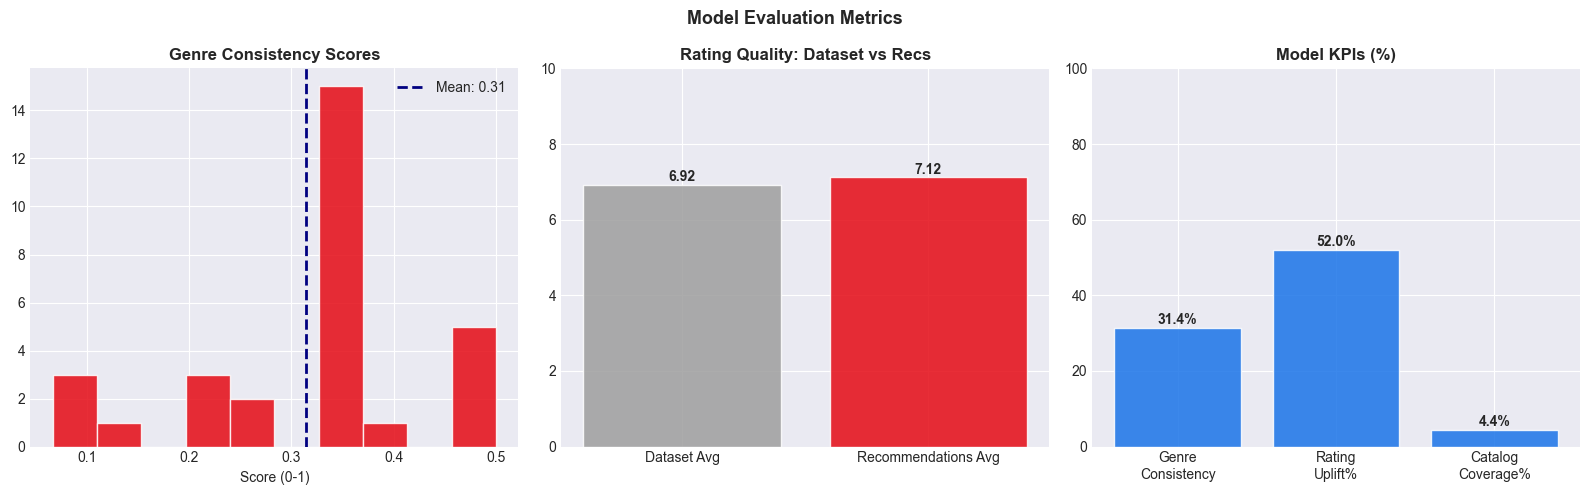

In [ ]:
# Evaluation visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Evaluation Metrics", fontsize=13, fontweight="bold")

axes[0].hist(consistency_scores, bins=10, color="#e50914", edgecolor="white", alpha=0.85)
axes[0].axvline(np.mean(consistency_scores), color="navy", linestyle="--", lw=2,
                label=f"Mean: {np.mean(consistency_scores):.2f}")
axes[0].set_title("Genre Consistency Scores", fontweight="bold")
axes[0].set_xlabel("Score (0-1)"); axes[0].legend()

cats = ["Dataset Avg", "Recommendations Avg"]
vals = [df["vote_average"].mean(), np.mean(rating_scores)]
axes[1].bar(cats, vals, color=["#9e9e9e","#e50914"], edgecolor="white", alpha=0.85)
axes[1].set_ylim(0, 10)
axes[1].set_title("Rating Quality: Dataset vs Recs", fontweight="bold")
for i, v in enumerate(vals):
    axes[1].text(i, v+0.1, f"{v:.2f}", ha="center", fontweight="bold")

metrics = ["Genre\nConsistency", "Rating\nUplift%", "Catalog\nCoverage%"]
vals2 = [np.mean(consistency_scores)*100,
         min(max((np.mean(rating_scores)-df["vote_average"].mean())/10*100+50, 0),100),
         coverage]
axes[2].bar(metrics, vals2, color="#1a73e8", edgecolor="white", alpha=0.85)
axes[2].set_title("Model KPIs (%)", fontweight="bold")
axes[2].set_ylim(0, 100)
for i, v in enumerate(vals2):
    axes[2].text(i, v+1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../exports/fig_12_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()


# 15. Export for Power BI <a id="15-powerbi-export" name="15-powerbi-export"></a>

In [ ]:
# Define yearly trends aggregation
yearly = df.groupby("release_year").agg(
    total_films=("id", "count"),
    avg_rating=("vote_average", "mean"),
    median_rating=("vote_average", "median"),
    avg_runtime=("runtime", "mean"),
    avg_popularity=("popularity", "mean"),
    total_budget=("budget", "sum"),
    total_revenue=("revenue", "sum"),
    total_profit=("profit", "sum"),
    avg_roi=("roi", "mean"),
).round(2)

In [ ]:
import os
os.makedirs("../exports", exist_ok=True)

In [ ]:
# 1. Main movie table (all KPIs)
df_pbi = df[[
    "id","imdb_id","title","original_title","original_language",
    "overview","tagline","genres","primary_genre","n_genres",
    "release_date","release_year","release_month","release_quarter","release_decade",
    "runtime","runtime_category","budget","revenue","profit","roi","budget_tier",
    "popularity","popularity_tier","vote_average","vote_count","weighted_rating","rating_tier",
    "status","director","writer","cast",
    "production_companies_name","production_companies_country",
    "production_countries","spoken_languages","poster_path","backdrop_path",
]].copy()
df_pbi.to_csv("../exports/powerbi_movies.csv", index=False)
print(f"powerbi_movies.csv          — {df_pbi.shape}")

# 2. Genre exploded table
df_ge.to_csv("../exports/powerbi_genres.csv", index=False)
print(f" powerbi_genres.csv          — {df_ge.shape}")

# 3. Genre KPI summary
genre_kpi = df_ge.groupby("genre").agg(
    total_films=("title","count"),
    avg_rating=("vote_average","mean"),
    median_rating=("vote_average","median"),
    avg_runtime=("runtime","mean"),
    avg_votes=("vote_count","mean"),
    avg_popularity=("popularity","mean"),
    total_budget=("budget","sum"),
    total_revenue=("revenue","sum"),
).round(2).reset_index()
genre_kpi["rating_rank"] = genre_kpi["avg_rating"].rank(ascending=False).astype(int)
genre_kpi.to_csv("../exports/powerbi_genre_kpi.csv", index=False)
print(f" powerbi_genre_kpi.csv       — {genre_kpi.shape}")

# 4. Ratings/interactions
df_ratings.to_csv("../exports/powerbi_ratings.csv", index=False)
print(f" powerbi_ratings.csv         — {df_ratings.shape}")

# 5. Director analytics
dir_stats.reset_index().to_csv("../exports/powerbi_directors.csv", index=False)
print(f" powerbi_directors.csv       — {dir_stats.shape}")

# 6. Yearly trends
yearly.reset_index().to_csv("../exports/powerbi_yearly_trends.csv", index=False)
print(f" powerbi_yearly_trends.csv   — {yearly.shape}")

# 7. Production country table
ctry_df = pd.DataFrame({"country": ctry_list})
ctry_agg = ctry_df.groupby("country").size().reset_index(name="film_count").sort_values("film_count",ascending=False)
ctry_agg.to_csv("../exports/powerbi_countries.csv", index=False)
print(f" powerbi_countries.csv       — {ctry_agg.shape}")

# 8. Language table
lang_df = df.groupby("original_language").agg(
    film_count=("id","count"),
    avg_rating=("vote_average","mean"),
    avg_popularity=("popularity","mean")
).reset_index().sort_values("film_count",ascending=False)
lang_df.to_csv("../exports/powerbi_languages.csv", index=False)
print(f" powerbi_languages.csv       — {lang_df.shape}")


powerbi_movies.csv          — (5261, 38)
 powerbi_genres.csv          — (14377, 13)
 powerbi_genre_kpi.csv       — (19, 10)
 powerbi_ratings.csv         — (16923, 3)
 powerbi_directors.csv       — (530, 5)
 powerbi_yearly_trends.csv   — (107, 9)
 powerbi_countries.csv       — (85, 2)
 powerbi_languages.csv       — (39, 4)
